In [166]:
# Standard library imports
import os
import sys
import re
import itertools
import glob
import pickle
import zipfile

# Third-party imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import linregress
import geopandas as gpd
import mpmath
import cmocean
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from tqdm import tqdm
from scipy import stats, optimize as opt, signal
from scipy.special import hyp2f1, betainc
from matplotlib.colors import TwoSlopeNorm, LogNorm
from matplotlib.ticker import (
    ScalarFormatter, LogLocator, LogFormatterMathtext, LogFormatter,
    AutoMinorLocator, MultipleLocator, NullFormatter
)
from matplotlib.markers import MarkerStyle
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
import matplotlib.image as mpimg

# Figure and plotting settings
fig_formats = ['.pdf', '.eps', '.tiff', '.png']
golden = (1 + 5 ** 0.5) / 2
cms = 0.393701
figsize = (golden * 8 * cms, 8 * cms)
figsizes = {
    "1 column": (3.43, 3.43 / golden),
    "1.5 columns": (4.49, 4.49 / golden),
    "2 columns": (7.01, 7.01 / golden)
}

# Color palettes
light_palette = ['#504B43', '#4caf50', '#948d99']
dark_palette = ['#285DB1', '#AC3127', '#c1bbb0']
color_clusters = ['#648fff', '#ffb000', '#948d99']
paletteTGB = ['#4caf50', '#504B43', '#948d99']
metaTcolor, metaGcolor, metaBcolor = paletteTGB
metacolor = {'metaT': metaTcolor, 'metaG': metaGcolor, 'metaB': metaBcolor}
metamarker = {'metaT': 'o', 'metaG': 'd', 'metaB': 's'}
palettename = 'coolwarm'
palette_temp = sns.color_palette(palettename, 32)

# Load world map data
# world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))
import geodatasets
world = gpd.read_file(geodatasets.get_path("naturalearth.land"))

# Seaborn and matplotlib settings
sns.set_theme(
    rc={
        'figure.figsize': figsizes["2 columns"],
        'figure.dpi': 200,
        'savefig.dpi': 300
    },
    font="Helvetica Neue",
    font_scale=1.3,
    style="ticks"
)

plt.rcParams.update({
    'legend.edgecolor': 'k',
    'legend.facecolor': 'w',
    'legend.frameon': True,
    'legend.framealpha': 1,
    'legend.fancybox': False,
    'legend.fontsize': 12,
    'axes.linewidth': 1.5,
    'axes.edgecolor': 'k',
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'axes.labelsize': 14,
    "text.usetex": True,
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica"],
    "text.latex.preamble": r"\usepackage{amsmath, helvet} \renewcommand{\familydefault}{\sfdefault}"
})

# Jupyter autoreload magic
%reload_ext autoreload
%autoreload 1

In [167]:
def return_xi_and_error(E, sigma_E, eps, sigma_eps):
    xi = 1. / (1. + E / eps)
    sigma_xi = xi**2 * np.sqrt( (sigma_E / eps)**2 + (E * sigma_eps / eps**2)**2 )
    return xi, sigma_xi

In [168]:
def log_hist(data, nbins=30):    
    data_positive = data[data > 0]
    bins = np.logspace(np.log10(data_positive.min()), np.log10(data_positive.max()), nbins)
    counts = np.histogram(data_positive, bins=bins)[0]
    prob = counts / counts.sum()
    pdf = prob / np.diff(bins)
    return bins, counts, prob, pdf

def return_color_station(station, metadata, palette_temp=palette_temp):
    # if station is a string convert to integer
    if isinstance(station, str):
        station = int(station)
    temperature = int(metadata.loc[station, 'temp_woa'])+1
    return palette_temp[temperature]

def plot_logSAD(data, nbins=20):
    bins, counts, prob, pdf = log_hist(data, nbins=nbins)
    xx = np.sqrt(bins[:-1]*bins[1:])
    yy = pdf
    xx = xx[yy>0]
    yy = yy[yy>0]
    return xx, yy

def plot_logrescaledSAD(data, nbins=20):
    data = data[data>0]
    y = np.log(data)
    z = (y-np.mean(y))/np.std(y)
    hist, bins = np.histogram(z, bins=nbins, density=True)
    xx = (bins[1:] + bins[:-1])/2
    yy = hist
    xx = xx[yy>0]
    yy = yy[yy>0]
    return xx, yy

def paretoDistribution(x, k, a, c, mu):
    if x >= mu:
        pdf = (k**(-1/c) * a * (1 + ((x - mu)/k)**(1/c))**(-1 - a) * (x - mu)**(-1 + 1/c)) / c
    else:
        pdf = 0
    return pdf

In [169]:
def log_pdf(data, nbins=20):
    if len(data) < 3:
        return np.array([]), np.array([]), np.array([]), np.array([])
    else:
        positive_data = data[data > 0]
        bins = np.logspace(np.log10(np.min(positive_data)), np.log10(np.max(positive_data)), nbins)
        hist, _ = np.histogram(positive_data, bins=bins, density=False)
        prob = hist / np.sum(hist)
        pdf = prob / np.diff(bins)
        x_plot = np.sqrt(bins[1:] * bins[:-1])
        y_plot = pdf
        x_plot = x_plot[y_plot > 0]
        y_plot = y_plot[y_plot > 0]
        return x_plot, y_plot, pdf, bins 

def fit_log_generalized_gamma(x, y):
    def log_generalized_gamma(X, a, b, C):
        return np.log(C) + (-1+a)*X - b*np.exp(X)
    if len(x) < 3:
        return np.array([np.nan, np.nan, np.nan])
    else:
        X = np.log(x)
        Y = np.log(y)
        popt, _ = opt.curve_fit(log_generalized_gamma, X, Y, p0=[1, 1, 1], bounds=([-5, 0, 1e-9], [5, np.inf, np.inf]))
        return popt
    
def fit_log_pareto3exp(x, y):
    def log_pareto3exp(X, alpha, beta, k):
        return np.log(pareto3exp(np.exp(X), alpha, beta, k))
    if len(x) < 3:
        return np.array([np.nan, np.nan, np.nan])
    else:
        X = np.log(x)
        Y = np.log(y)
        popt, _ = opt.curve_fit(log_pareto3exp, X, Y, p0=[0.5, 0.0001, 1], bounds=([1e-9, 1e-9, 1e-9], [5, np.inf, np.inf]))
        return popt
    
    # y = C * x**(-1+a) * np.exp(-b*x)
    # logy = log(C) + (-1+a)*log(x) - b*x
    # X = log(x)
    # x = exp(X)

def plotSAD(
    b0, d0, b1, d1, t0, gamma0, t1, gamma1, t_max, n_x, PDF_x, n_y, PDF_y, popt_x, popt_y,
    Delta=0, chain=0, kG=None, zetaG=None, alphaG=None, kT=None, zetaT=None, alphaT=None, nmin=1e-1
):
    fig, axes = plt.subplots(1, 2, figsize=(figsizes["2 columns"][0], 0.5 * figsizes["2 columns"][1]), constrained_layout=True)
    title = f"Chain {chain} - $b_0={b0:.4f}$, $d_0={d0:.4f}$, $b_1={b1:.4f}$, $d_1={d1:.4f}$, $t_0={t0:.4f}$, $\\gamma_0={gamma0:.4f}$, $t_1={t1:.4f}$, $\\gamma_1={gamma1:.4f}$, $t_{{max}}={t_max}$, $\\Delta={Delta:1.1f}$"
    fig.suptitle(title, fontsize=7)

    if kG is None:
        kG = return_kG(b0, d0, b1, d1)
    if alphaG is None:
        alphaG = return_alphaG(b0, d0, b1, d1)
    if zetaG is None:
        zetaG = max((b0 - d0) / (b1 + d1), 1e-12)
    if kT is None:
        kT = return_kT(b0, d0, b1, d1, t0, gamma1)
    if alphaT is None:
        alphaT = alphaG
    if zetaT is None:
        zetaT = zetaG

    nmin_plot = max(nmin, np.min(np.concatenate([n_x[n_x > 0], n_y[n_y > 0]])))

    axes[0].set_xscale('log')
    axes[0].set_yscale('log')
    axes[0].set_xlabel("DNA")
    axes[0].set_ylabel("PDF")
    axes[0].scatter(n_x, PDF_x, color=light_palette[0], alpha=1, edgecolor='k', lw=0.5, s=15)
    x_plot, y_plot = beta_prime_curve(n_x, k=kG, zeta=zetaG, alpha=alphaG, nmin=nmin_plot)
    axes[0].plot(x_plot, y_plot, color=light_palette[0], alpha=0.95, ls='-', zorder=-1)
    axes[0].text(0.1, 0.15, f'$\\zeta={zetaG:.2f}$\n$\\alpha={alphaG:.2f}$\n$k={kG:.2f}$', transform=axes[0].transAxes, fontsize=8)

    axes[1].set_xscale('log')
    axes[1].set_yscale('log')
    axes[1].set_xlabel("RNA")
    axes[1].set_ylabel("PDF")
    axes[1].scatter(n_y, PDF_y, color=light_palette[1], alpha=1, edgecolor='k', lw=0.5, s=15)
    x_plot, y_plot = beta_prime_curve(n_y, k=kT, zeta=zetaT, alpha=alphaT, nmin=nmin_plot)
    axes[1].plot(x_plot, y_plot, color=light_palette[1], alpha=0.95, ls='-')
    axes[1].text(0.1, 0.15, f'$\\zeta={zetaT:.2f}$\n$\\alpha={alphaT:.2f}$\n$k={kT:.2f}$', transform=axes[1].transAxes, fontsize=8)

    os.makedirs('langevin/figures', exist_ok=True)
    figname = f'langevin/figures/langevin_chain_{chain}_b0_{b0:.4f}_d0_{d0:.4f}_b1_{b1:.4f}_d1_{d1:.4f}_t0_{t0:.4f}_gamma0_{gamma0:.4f}_t1_{t1:.4f}_gamma1_{gamma1:.4f}_tmax_{t_max}_Delta_{Delta:1.1f}.pdf'
    fig.savefig(figname, dpi=200)
    plt.show()
    return fig, axes

def plotCORR(datax, datay, b0, d0, b1, d1, t0, gamma0, t1, gamma1, t_max, Delta, chain=0):
    fig, ax = plt.subplots(figsize=(3,3), constrained_layout=True)
    sns.scatterplot(x=datax, y=datay, s=5, lw=0.5, edgecolor='k', alpha=0.5, ax=ax,color='orange')
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel('DNA')
    ax.set_ylabel('RNA')
    ax.grid(True)
    
    R2 = np.corrcoef(datax, datay)[0,1]**2
    ax.text(0.6, 0.9, f'$R^2={R2:.2}$', transform=ax.transAxes, fontsize=8, verticalalignment='center', bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.2'))
    
    xmin = np.log10(np.min(datax[datax>10]))
    x_plot = np.logspace(xmin, np.log10(datax.max()), 10)
    y_plot = x_plot*t0/gamma1
    y_plot_std = np.sqrt(y_plot)
    #sns.lineplot(x=x_plot, y=y_plot, lw=2, color='k', ls='--', zorder=1)
    #ax.errorbar(x=x_plot, y=y_plot, yerr = y_plot_std*3, color='k', zorder=1)
    
    figname = f'figures/scatter_langevin_chain_{chain}_b0_{b0:.4f}_d0_{d0:.4f}_b1_{b1:.4f}_d1_{d1:.4f}_t0_{t0:.4f}_gamma0_{gamma0:.4f}_t1_{t1:.4f}_gamma1_{gamma1:.4f}_tmax_{t_max}_Delta_{Delta:1.1f}_corr.pdf'
    fig.savefig(figname, dpi=200)
    
    
def return_alphaG(b0, d0, b1, d1):
    return 4.0 * (d0*b1-b0*d1)/(b1+d1)**2
def return_kG(b0, d0, b1, d1):
    return (d0+b0)/(d1+b1)
def return_betaG(b0, d0, b1, d1):
    return 2*(d1-b1)/(b1+d1)

def return_kT(b0, d0, b1, d1, t0, gamma1):
    return (d0+b0)/(d1+b1)*t0/gamma1
def return_betaT(b0, d0, b1, d1, t0, gamma1):
    return 2*(d1-b1)/(b1+d1)*gamma1/t0

def sad_to_rates(kG, zetaG, alphaG, sigma_e2=0.05, b1_target=1.0):
    sigma_d2 = kG * sigma_e2
    mu = 0.5 * zetaG * sigma_d2
    d = 0.5 * (alphaG - 1.0) * sigma_e2
    d1 = (sigma_d2 + d) / 2.0
    b1 = (sigma_d2 - d) / 2.0
    scale = b1_target / b1
    b1 *= scale
    d1 *= scale
    mu *= scale
    sigma_d2 *= scale
    sigma_e2 *= scale
    b0 = max(mu, 0.0)
    d0 = max(-mu, 0.0)
    return {"b0": b0, "b1": b1, "d0": d0, "d1": d1, "sigma_d2": sigma_d2, "sigma_e2": sigma_e2}

def set_rna_rates(kG, kT, r=1000.0):
    gamma = kG * r / kT
    return {"r": r, "gamma": gamma}

def sad_parameters(k, zeta, alpha):
    return {"k": k, "logk": np.log10(k), "a": zeta, "b": alpha - 1.0, "alpha": alpha}

# def cumul_env(n, k, zeta, alpha):
#     n = np.asarray(n, dtype=float)
#     return sp.special.betainc(zeta, alpha, n / (n + k))

def cumul(n,a,b,logk):
    return betainc(a, 1.0 + b, n / (n + 10**logk))

def envdem(n,a,b,logk,nmin):
    return stats.betaprime.pdf(n / 10**logk, a, b + 1) / 10**logk / (1.0 - cumul(nmin, a, b, logk))

# def envdem(n, k, zeta, alpha, nmin):
#     n = np.asarray(n, dtype=float)
#     norm = 1.0 - cumul_env(nmin, k, zeta, alpha)
#     return sp.stats.betaprime.pdf(n / k, zeta, alpha) / k / norm

def sad_meta_params(kG, zetaG, alphaG, kT):
    return {
        "metaG": sad_parameters(kG, zetaG, alphaG),
        "metaT": sad_parameters(kT, zetaG, alphaG),
    }

def beta_prime_curve(n_data, k, zeta, alpha, nmin, xmax_factor=1.6, npts=200):
    n_data = np.asarray(n_data, dtype=float)
    n_data = n_data[n_data > 0]
    x_plot = np.logspace(np.log10(n_data.min()), np.log10(xmax_factor * n_data.max()), npts)
    y_plot = envdem(x_plot, zeta, alpha - 1.0, np.log10(k), nmin)
    return x_plot, y_plot


In [170]:
metadata = pd.read_csv('../data/temperature/TARA_env_table.csv', index_col=0, sep=',')
metadata = metadata.rename(columns={'lon': 'longitude', 'lat': 'latitude', 'SST_mn': 'temp_woa'})
metadata.index = metadata.index.astype(int)
metadata = gpd.GeoDataFrame(metadata, geometry=gpd.points_from_xy(metadata.longitude, metadata.latitude), crs="ESRI:54030")
metadata['temp_category'] = pd.cut(metadata.temp_woa, bins=[-np.inf, 15, np.inf], labels=['low', 'high'])
metadata['inverseTemperature'] = 1000/(metadata['temp_woa']+273.15)
metadata['color'] = metadata.index.map(lambda x: return_color_station(x, metadata))
display(metadata.head())


,longitude,latitude,temp_woa,SST_sd,geometry,temp_category,inverseTemperature,color
station,,,,,,,,
1,-9.833,44.415,14.754890,2.604555,POINT (-9.833 44.415),low,3.473369,"(0.8513716370313725, 0.8631253107372548, 0.881..."
2,-10.790,39.038,17.257492,2.383813,POINT (-10.79 39.038),high,3.443437,"(0.933221183, 0.8155568504470588, 0.7531514321..."
3,-10.421,36.672,18.647820,2.019803,POINT (-10.421 36.672),high,3.427030,"(0.9509556129803922, 0.7868750333333333, 0.704..."
4,-6.553,36.563,18.304092,2.840920,POINT (-6.553 36.563),high,3.431072,"(0.9509556129803922, 0.7868750333333333, 0.704..."
5,-4.405,36.030,17.898531,2.463223,POINT (-4.405 36.03),high,3.435853,"(0.933221183, 0.8155568504470588, 0.7531514321..."


In [171]:
DATA_NORMALIZATION = "norm"  # either "norm" or "raw"
meta_data_dir = "../data/filter/metaGT_micro_bacilla"
meta_prefix = f"{DATA_NORMALIZATION}Counts"
metaT_path = f"{meta_data_dir}/{meta_prefix}_metaT_micro_bacilla.csv"
metaG_path = f"{meta_data_dir}/{meta_prefix}_metaG_micro_bacilla.csv"
# Fallback to legacy flat files if normalized files are unavailable
if not os.path.exists(metaT_path):
    metaT_path = "../data/metaT_micro_bacilla.csv"
if not os.path.exists(metaG_path):
    metaG_path = "../data/metaG_micro_bacilla.csv"
metaT = pd.read_csv(metaT_path, index_col=0)
metaG = pd.read_csv(metaG_path, index_col=0)
metaT.columns = metaT.columns.astype(int)
metaG.columns = metaG.columns.astype(int)
df_meta = {"metaT": metaT, "metaG": metaG}
df_meta_relative = {key: df.div(df.sum(axis=0), axis=1) for key, df in df_meta.items()}
del metaT, metaG


KeyboardInterrupt: 

In [ ]:
# metaT = pd.read_csv(f'metaGT_lengthnorm_micro_bacilla/metaT_micro_bacilla.csv', index_col=0)
# metaG = pd.read_csv(f'metaGT_lengthnorm_micro_bacilla/metaG_micro_bacilla.csv', index_col=0)

In [ ]:
# # metaT = pd.read_csv(f'../data/metaT_micro_bacilla.csv', index_col=0)
# # metaG = pd.read_csv(f'../data/metaG_micro_bacilla.csv', index_col=0)
# metaT.columns = metaT.columns.astype(int)
# metaG.columns = metaG.columns.astype(int)
# # /Users/epigani/Library/CloudStorage/GoogleDrive-emanuele.pigani.1@unipd.it/.shortcut-targets-by-id/17Sn-Ra2REh5B86l96gE_Smchh22WCsgo/PhD-Emanuele Pigani/finished_projects/Pigani HayMele et al 2024/downscaling_richness/data/Abundance.csv
# #metaB = pd.read_csv(f'{directory}/metaB_micro/Abundances_C.csv', index_col=0)

# df_meta = {'metaT': metaT, 'metaG': metaG}
# df_meta_relative = {key: df.div(df.sum(axis=0), axis=1) for key, df in df_meta.items()}

# del metaT, metaG


In [ ]:
# filename = 'metaGT_lengthnorm_micro_bacilla/metaT_micro_bacilla_fit.csv'
# fit_metaT = pd.read_csv(filename)
# filename = 'metaGT_lengthnorm_micro_bacilla/metaG_micro_bacilla_fit.csv'
# fit_metaG = pd.read_csv(filename)
# # use the index of df_meta for fit_metaT and fit_metaG
# fit_metaT.index = df_meta['metaT'].columns.astype(int)
# fit_metaG.index = df_meta['metaG'].columns.astype(int)
# #fit_metaT['k_cum_model'] = np.maximum(10**fit_metaT['logk_cum'] - fit_metaT['mu_cum'], fit_metaT['mu_cum'])
# fit_metaT['k_KS_model'] = fit_metaT['k']#np.maximum(10**fit_metaT['logk'] - fit_metaT['mu_KS'], fit_metaT['mu_KS'])
# #fit_metaG['k_cum_model'] = np.maximum(10**fit_metaG['logk_cum'] - fit_metaG['mu_cum'], fit_metaG['mu_cum'])
# fit_metaG['k_KS_model'] = fit_metaG['k']#np.maximum(10**fit_metaG['logk'] - fit_metaG['mu_KS'], fit_metaG['mu_KS'])

# df_fits = {'metaT': fit_metaT, 'metaG': fit_metaG}

# for meta in ['metaT', 'metaG']: 
#     df_fits[meta]['N_filtered'] = {station: df_meta[meta].loc[df_meta[meta][station]>df_fits[meta].loc[station, 'mu'], station].fillna(0).sum() for station in df_meta[meta].columns}
#     df_fits[meta]['S_filtered'] = {station: df_meta[meta].loc[df_meta[meta][station]>df_fits[meta].loc[station, 'mu'], station].fillna(0).astype(bool).sum() for station in df_meta[meta].columns}
#     df_fits[meta]['mean_n_filtered'] = df_fits[meta]['N_filtered']/df_fits[meta]['S_filtered']
#     df_fits[meta]['n_max'] = {station: df_meta[meta][station].max() for station in df_meta[meta].columns}
#     df_fits[meta]['fitted_decades'] = np.log10(df_fits[meta]['n_max']) - np.log10(df_fits[meta]['mu'])

In [ ]:
def resolve_fit_file(meta_key):
    primary = f"../fit/summary_fit_{DATA_NORMALIZATION}Counts_betaprimemintransf_{meta_key}_micro_bacilla.csv"
    fallback = f"../fit/summary_fit_{meta_key}_micro_bacilla.csv"
    return primary if os.path.exists(primary) else fallback
fit_metaT = pd.read_csv(resolve_fit_file("metaT"), index_col=0)
fit_metaG = pd.read_csv(resolve_fit_file("metaG"), index_col=0)
# fit_metaT['k_cum_model'] = np.maximum(10**fit_metaT['logk_cum'] - fit_metaT['mu_cum'], fit_metaT['mu_cum'])
fit_metaT["k_model"] =10**fit_metaT["logk"]
# fit_metaG['k_cum_model'] = np.maximum(10**fit_metaG['logk_cum'] - fit_metaG['mu_cum'], fit_metaG['mu_cum'])
fit_metaG["k_model"] = 10**fit_metaG["logk"]
df_fits = {"metaT": fit_metaT, "metaG": fit_metaG}
for meta in ["metaT", "metaG"]:
    df_fits[meta]["N_filtered"] = {
        station: df_meta[meta].loc[df_meta[meta][station] > df_fits[meta].loc[station, "nmin"], station].fillna(0).sum()
        for station in df_meta[meta].columns
    }
    df_fits[meta]["S_filtered"] = {
        station: df_meta[meta].loc[df_meta[meta][station] > df_fits[meta].loc[station, "nmin"], station].fillna(0).astype(bool).sum()
        for station in df_meta[meta].columns
    }
    # df_fits[meta]["mean_n_filtered"] = df_fits[meta]["N_filtered"] / df_fits[meta]["S_filtered"]
    # df_fits[meta]["n_max"] = {station: df_meta[meta][station].max() for station in df_meta[meta].columns}
    # df_fits[meta]["fitted_decades"] = np.log10(df_fits[meta]["n_max"]) - np.log10(df_fits[meta]["mu_KS"])


In [ ]:
fit_metaT.head()

,N_10,S_10,nmin,alpha,alpha_low,alpha_high,beta,beta_low,beta_high,logk,...,logN_mean,logN_low,logN_high,KS,p_KS,CvM,p_CvM,k_model,N_filtered,S_filtered
station,,,,,,,,,,,,,,,,,,,,,
7,54.485008,441,0.000537,3.163857,0.0,0.0,0.226103,0.0,0.0,-1.860856,...,-inf,NaN,NaN,0.618455,0.002,77.477247,0.002,0.013777,54.484471,440
11,22.000835,167,0.004491,1.143322,0.0,0.0,0.809566,0.0,0.0,-1.106086,...,-inf,NaN,NaN,0.157769,0.002,1.036167,0.002,0.078327,21.996344,166
18,54.740060,368,0.002961,3.167301,0.0,0.0,0.092226,0.0,0.0,-1.919945,...,-inf,NaN,NaN,0.503882,0.002,45.368770,0.002,0.012024,54.737099,367
22,39.059121,608,0.000902,2.189995,0.0,0.0,1.020265,0.0,0.0,-1.523417,...,-inf,NaN,NaN,0.212828,0.002,14.217160,0.002,0.029963,39.058219,607
23,88.527040,618,0.001504,6.666667,0.0,0.0,0.057871,0.0,0.0,-2.349565,...,-inf,NaN,NaN,0.674053,0.002,125.690483,0.002,0.004471,88.525536,617


In [ ]:
gdf = metadata.copy()
gdf['mean_metaT'] = df_meta['metaT'].sum(axis=0)/df_meta['metaT'].astype(bool).sum(axis=0)
gdf['mean_metaG'] = df_meta['metaG'].sum(axis=0)/df_meta['metaG'].astype(bool).sum(axis=0)
gdf['total_metaT'] = df_meta['metaT'].sum(axis=0)
gdf['total_metaG'] = df_meta['metaG'].sum(axis=0)
gdf['mu_metaT'] = df_fits['metaT']['nmin']
gdf['mu_metaG'] = df_fits['metaG']['nmin']
gdf['alpha_metaT'] = df_fits['metaT']['alpha']
gdf['alpha_metaG'] = df_fits['metaG']['alpha']
gdf['beta_metaT'] = df_fits['metaT']['beta']
gdf['beta_metaG'] = df_fits['metaG']['beta']
gdf['k_metaT'] = df_fits['metaT']['k_model']
gdf['k_metaG'] = df_fits['metaG']['k_model']
# gdf['k_sup_metaT'] = df_fits['metaT']['k_high']
# gdf['k_sup_metaG'] = df_fits['metaG']['k_high']
# gdf['k_inf_metaT'] = df_fits['metaT']['k_low']
# gdf['k_inf_metaG'] = df_fits['metaG']['k_low']

# gdf['alpha_sup_metaT'] = df_fits['metaT']['alpha_high']
# gdf['alpha_sup_metaG'] = df_fits['metaG']['alpha_high']
# gdf['alpha_inf_metaT'] = df_fits['metaT']['alpha_low']
# gdf['alpha_inf_metaG'] = df_fits['metaG']['alpha_low']

gdf['inverseTemperature'] = 1000/(gdf['temp_woa']+273.15)
gdf['kT/kG'] = gdf['k_metaT']/gdf['k_metaG']

# filter gdf only to stations where k_metaG is non nan
gdf = gdf[gdf['k_metaG'].notna()]

In [ ]:
N_metaT = df_meta['metaT'].sum(axis=0)
S_metaT = df_meta['metaT'].fillna(0).astype(bool).sum(axis=0)
N_metaG = df_meta['metaG'].sum(axis=0)
S_metaG = df_meta['metaG'].fillna(0).astype(bool).sum(axis=0)

# Figures S2-S6

First block makes 6x4 panels, second block makes 8x4 panels.

In [ ]:
df_fits[meta].columns

Index(['N_10', 'S_10', 'nmin', 'alpha', 'alpha_low', 'alpha_high', 'beta',
       'beta_low', 'beta_high', 'logk', 'logk_low', 'logk_high', 'logN_mean',
       'logN_low', 'logN_high', 'KS', 'p_KS', 'CvM', 'p_CvM', 'k_model',
       'N_filtered', 'S_filtered'],
      dtype='object')

In [ ]:
figsize = (9.27, 11.69)
labelsize = 10
plt.rcParams['text.usetex'] = True

# --- CONFIGURATION FOR 6x4 GRID ---
# 6 rows * 4 columns = 24 plots total.
# Since each station needs 2 plots, we fit 12 stations per page.
STATIONS_PER_PAGE = 12 
TOTAL_AXES = 24
BOTTOM_ROW_START_IDX = 20 # Indices 20, 21, 22, 23 are the bottom row

for i, station in enumerate(df_meta['metaT'].columns):
    # 1. Change loop condition to create a new figure every 12 stations
    if i % STATIONS_PER_PAGE == 0:
        # Create 6 rows, 4 columns
        fig, axes = plt.subplots(6, 4, figsize=figsize, constrained_layout=True, gridspec_kw={'hspace': 0.1})

        for i_ax, ax in enumerate(axes.flatten()):
            # set font size of the axes
            ax.tick_params(axis='both', which='major', labelsize=labelsize)
            ax.set_xscale('log')
            ax.set_yscale('log')
            
            if i_ax % 4 == 0:
                ax.set_ylabel('PDF', fontsize=labelsize)
            
            # 2. Update x-label position: The bottom row starts at index 20 (for a 6x4 grid)
            if i_ax >= BOTTOM_ROW_START_IDX:
                ax.set_xlabel('abundance', fontsize=labelsize)
                
            if i_ax < 4:
                if i_ax % 2 == 0:
                    ax.set_title('metaG', fontsize=labelsize)
                else:
                    ax.set_title('metaT', fontsize=labelsize)
            ax.grid(True, lw=0.35, ls='--', alpha=0.5)
            
            ax.xaxis.set_minor_locator(LogLocator(base=10.0, subs=[], numticks=10)) 
            ax.xaxis.set_minor_formatter(NullFormatter())   

            # Customize grid
            ax.xaxis.set_major_locator(LogLocator(base=10.0, numticks=10))
            ax.yaxis.set_major_locator(LogLocator(base=10.0, numticks=10))
            ax.xaxis.set_major_formatter(LogFormatterMathtext())
            ax.yaxis.set_major_formatter(LogFormatterMathtext())
            
    for meta in ['metaT', 'metaG']:
        df = df_meta[meta]
        data = df[station]
        fit = df_fits[meta].loc[station]
        a, b, logk, nmin = fit['alpha'], fit['beta'], fit['logk'], fit['nmin']
        data = data[~data.isna()]
        data = data[data >= nmin]
        x, y = plot_logSAD(data, nbins=20)
        
        # 3. Update the indexing logic using modulo 24 (TOTAL_AXES) instead of 32
        if meta == 'metaT':
            ax = axes.flatten()[(2*i) % TOTAL_AXES + 1]
        else:
            ax = axes.flatten()[(2*i) % TOTAL_AXES]
            
        sns.lineplot(x=x, y=y, ax=ax, color=metacolor[meta], lw=0.3, marker=metamarker[meta], markersize=4.5, markeredgecolor='k')

        xlim_inf, xlim_sup = 10**np.floor(np.log10(data.min())), 10**np.ceil(np.log10(data.max()))
        ax.set_xlim(xlim_inf, xlim_sup)
        xticks = 10**np.arange(np.floor(np.log10(data.min())), np.ceil(np.log10(data.max()))+1, 1)
        ax.set_xticks(xticks)

        x_plot = np.logspace(np.log10(max(1.00001 * data.min(), nmin * (1.00001 if nmin > 0 else 1.0))), np.log10(data.max()), 100)
        y_plot = np.asarray([envdem(xx, a, b, logk, nmin) for xx in x_plot])
        positive_fit = y_plot[y_plot > 0]
        ylim_inf, ylim_sup = 10**np.floor(np.log10(min(y.min(), positive_fit.min()))), 10**np.ceil(np.log10(max(y.max(), positive_fit.max())))
        ax.set_ylim(ylim_inf, ylim_sup)
        
        if np.ceil(np.log10(max(y.max(), positive_fit.max()))) - np.floor(np.log10(min(y.min(), positive_fit.min()))) > 5:
            yticks = 10**np.arange(np.floor(np.log10(min(y.min(), positive_fit.min()))), np.ceil(np.log10(max(y.max(), positive_fit.max())))+1, 2)
        else:
            yticks = 10**np.arange(np.floor(np.log10(min(y.min(), positive_fit.min()))), np.ceil(np.log10(max(y.max(), positive_fit.max())))+1, 1)
        ax.set_yticks(yticks)
        
        sns.lineplot(x=x_plot, y=y_plot, ax=ax, color=metacolor[meta], lw=3.3, ls='--', zorder=0)
        text = 'station: ' + str(station)
        ax.text(0.95, 0.95, text, transform=ax.transAxes, ha='right', va='top', size=labelsize)
        
        print_pvalues = False
        if print_pvalues:
            pvalue_KS = fit['p_KS']
            pvalue_AD = fit['p_AD']
            if pvalue_KS >= 0.01:
                text = r"$p_K$ = {0:1.2f}".format(pvalue_KS)
            else:
                text = r"$p_K$ < 0.01"
            text += '\n'
            if pvalue_AD >= 0.01:
                text += r"$p_A$ = {0:1.2f}".format(pvalue_AD)
            else:  
                text += r"$p_A$ < 0.01"
            ax.text(0.05, 0.05, text, transform=ax.transAxes, ha='left', va='bottom', size=labelsize-2) 
        
        axg = ax.inset_axes([0.05, 0.05, 0.48, 0.4], zorder=-10)
        gpd.plotting.plot_dataframe(world, ax=axg, color='white', edgecolor='#d6d6d6', alpha=1., lw=.75)
        axg.scatter(metadata.loc[station, 'longitude'], metadata.loc[station, 'latitude'], marker='+', color='black', s=150, zorder=10)
        axg.set_axis_off()
        
    # 4. Save if it's the last station overall
    if i == len(df_meta['metaT'].columns)-1:
        # Optional: remove empty axes if the last page isn't full
        current_idx = (2*i) % TOTAL_AXES + 2 # +2 because we just filled index and index+1
        for empty_ax_idx in range(current_idx, TOTAL_AXES):
            fig.delaxes(axes.flatten()[empty_ax_idx])
            
        figname = f"../figures/{DATA_NORMALIZATION}/SM/SADs_all_page{(i//STATIONS_PER_PAGE) + 1}"
        print(f"Saving final page with {i%STATIONS_PER_PAGE + 1} stations (page {(i//STATIONS_PER_PAGE) + 1}) to {figname}.pdf and .png")   
        os.makedirs(os.path.dirname(figname), exist_ok=True)
        for fmt in [".pdf", ".png"]:
            plt.savefig(f"{figname}{fmt}", dpi=300, bbox_inches="tight", transparent=True)
            
        # figname = 'figures/SM/SADs_all_{}.png'.format(i//STATIONS_PER_PAGE + 1)
        #os.makedirs('figures/SM/', exist_ok=True)
        # fig.savefig(figname, dpi=300, bbox_inches='tight')
        plt.close(fig)
    
    # 5. Save if the page is full (every 12th station, index 11, 23, etc.)
    elif i % STATIONS_PER_PAGE == (STATIONS_PER_PAGE - 1):
        figname = f"../figures/{DATA_NORMALIZATION}/SM/SADs_all_page{(i//STATIONS_PER_PAGE) + 1}"
        os.makedirs(os.path.dirname(figname), exist_ok=True)
        for fmt in [".pdf", ".png"]:
            plt.savefig(f"{figname}{fmt}", dpi=300, bbox_inches="tight", transparent=True)
        # figname = 'figures/SM/SADs_all_{}.png'.format(i//STATIONS_PER_PAGE + 1)
        # os.makedirs('figures/SM/', exist_ok=True)
        # fig.savefig(figname, dpi=300, bbox_inches='tight')
        plt.close(fig)

Saving final page with 5 stations (page 7) to ../figures/norm/SM/SADs_all_page7.pdf and .png


In [ ]:
figsize=(8.27, 11.69)
labelsize=10
plt.rcParams['text.usetex'] = True

        
for i, station in enumerate(df_meta['metaT'].columns):
    if i % 16 == 0:
        if i < 16*4:
            fig, axes = plt.subplots(8, 4, figsize=figsize, constrained_layout=True, gridspec_kw={'hspace': 0.1})
        else:
            fig, axes = plt.subplots(7, 4, figsize=figsize, constrained_layout=True, gridspec_kw={'hspace': 0.1})
            # remove the last two axes
            axes[-1, -1].remove()
            axes[-1, -2].remove()

        for i_ax, ax in enumerate(axes.flatten()):
            # set font size of the axes to 12
            ax.tick_params(axis='both', which='major', labelsize=labelsize)
            ax.set_xscale('log')
            ax.set_yscale('log')
            if i_ax % 4 == 0:
                ax.set_ylabel('PDF', fontsize=labelsize)
            if i_ax >= 28:
                ax.set_xlabel('abundance', fontsize=labelsize)
            if i_ax < 4:
                if i_ax % 2 == 0:
                    ax.set_title('metaG', fontsize=labelsize)
                else:
                    ax.set_title('metaT', fontsize=labelsize)
            ax.grid(True, lw=0.35, ls='--', alpha=0.5)
            
            # ax.xaxis.set_minor_locator(plt.LogLocator(base=10.0, subs=np.arange(2, 10) * 0.1, numticks=10))
            # ax.yaxis.set_minor_locator(plt.LogLocator(base=10.0, subs=np.arange(2, 10) * 0.1, numticks=10))
            
            ax.xaxis.set_minor_locator(LogLocator(base=10.0, subs=[], numticks=10))  # No minor ticks
            ax.xaxis.set_minor_formatter(NullFormatter())   

            # Customize grid
            ax.xaxis.set_major_locator(LogLocator(base=10.0, numticks=10))
            ax.yaxis.set_major_locator(LogLocator(base=10.0, numticks=10))
            ax.xaxis.set_major_formatter(LogFormatterMathtext())
            ax.yaxis.set_major_formatter(LogFormatterMathtext())
            
    for meta in ['metaT', 'metaG']:
        df = df_meta[meta]
        data = df[station]
        fit = df_fits[meta].loc[station]
        a, b, logk, nmin = fit['alpha'], fit['beta'], fit['logk'], fit['nmin']
        data = data[~data.isna()]
        data = data[data >= nmin]
        x, y = plot_logSAD(data, nbins=20)
        if meta == 'metaT':
            ax = axes.flatten()[(2*i)%32+1]
        else:
            ax = axes.flatten()[(2*i)%32]
        sns.lineplot(x=x, y=y, ax=ax, color=metacolor[meta], lw=0.3, marker=metamarker[meta], markersize=4.5, markeredgecolor='k')

        xlim_inf, xlim_sup = 10**np.floor(np.log10(data.min())), 10**np.ceil(np.log10(data.max()))
        ax.set_xlim(xlim_inf, xlim_sup)
        xticks = 10**np.arange(np.floor(np.log10(data.min())), np.ceil(np.log10(data.max()))+1, 1)
        ax.set_xticks(xticks)
        # remove minor xticks
        x_plot = np.logspace(np.log10(max(1.00001 * data.min(), nmin * (1.00001 if nmin > 0 else 1.0))), np.log10(data.max()), 100)
        y_plot = np.asarray([envdem(xx, a, b, logk, nmin) for xx in x_plot])
        positive_fit = y_plot[y_plot > 0]
        ylim_inf, ylim_sup = 10**np.floor(np.log10(min(y.min(), positive_fit.min()))), 10**np.ceil(np.log10(max(y.max(), positive_fit.max())))
        ax.set_ylim(ylim_inf, ylim_sup)
        # if there are more than 5 decades, set the yticks every 2 decades
        if np.ceil(np.log10(max(y.max(), positive_fit.max()))) - np.floor(np.log10(min(y.min(), positive_fit.min()))) > 5:
            yticks = 10**np.arange(np.floor(np.log10(min(y.min(), positive_fit.min()))), np.ceil(np.log10(max(y.max(), positive_fit.max())))+1, 2)
        else:
            yticks = 10**np.arange(np.floor(np.log10(min(y.min(), positive_fit.min()))), np.ceil(np.log10(max(y.max(), positive_fit.max())))+1, 1)
        ax.set_yticks(yticks)
        
        
        sns.lineplot(x=x_plot, y=y_plot, ax=ax, color=metacolor[meta], lw=3.3, ls='--', zorder=0)
        text = 'station: ' + str(station)
        ax.text(0.95, 0.95, text, transform=ax.transAxes, ha='right', va='top', size=labelsize)
        #ax.set_title(station, fontsize=labelsize)
        
        pvalue_KS = fit['p_KS']
        pvalue_AD = fit['p_AD']
        if pvalue_KS >= 0.01:
            text = r"$p_K$ = {0:1.2f}".format(pvalue_KS)
        else:
            text = r"$p_K$ < 0.01"
        text += '\n'
        if pvalue_AD >= 0.01:
            text += r"$p_A$ = {0:1.2f}".format(pvalue_AD)
        else:  
            text += r"$p_A$ < 0.01"
        ax.text(0.05, 0.05, text, transform=ax.transAxes, ha='left', va='bottom', size=labelsize-2) 
        
        
        axg = ax.inset_axes([0.5, 0.45, 0.48, 0.4], zorder=-10)
        gpd.plotting.plot_dataframe(world, ax=axg, color='white', edgecolor='#d6d6d6', alpha=1., lw=.75)
        axg.scatter(metadata.loc[station, 'longitude'], metadata.loc[station, 'latitude'], marker='+', color='black', s=150, zorder=10)
        #title = r'#{0}: ({1:1.1f},{2:1.1f})'.format(station, metadata.loc[station, 'latitude'], metadata.loc[station, 'longitude'])
        #axg.set_title(title, fontsize=9)
        axg.set_axis_off()
        
    if i == len(df_meta['metaT'].columns)-1:
        # remove empty axes
        # for i_ax in range(i_ax+1, 32):
        #     fig.delaxes(axes.flatten()[i_ax])
        figname = 'figures/SM/SADs_all_{}.png'.format(i//16+1)
        os.makedirs('figures/SM/', exist_ok=True)
        fig.savefig(figname, dpi=300, bbox_inches='tight')
        plt.close(fig)
        
    if i % 16 == 15:
        figname = 'figures/SM/SADs_all_{}.png'.format(i//16+1)
        os.makedirs('figures/SM/', exist_ok=True)
        fig.savefig(figname, dpi=300, bbox_inches='tight')
        plt.close(fig)

# Figure S7

In [ ]:
df_fits[meta].columns

Index(['N_10', 'S_10', 'nmin', 'alpha', 'alpha_low', 'alpha_high', 'beta',
       'beta_low', 'beta_high', 'logk', 'logk_low', 'logk_high', 'logN_mean',
       'logN_low', 'logN_high', 'KS', 'p_KS', 'CvM', 'p_CvM', 'k_model',
       'N_filtered', 'S_filtered'],
      dtype='object')

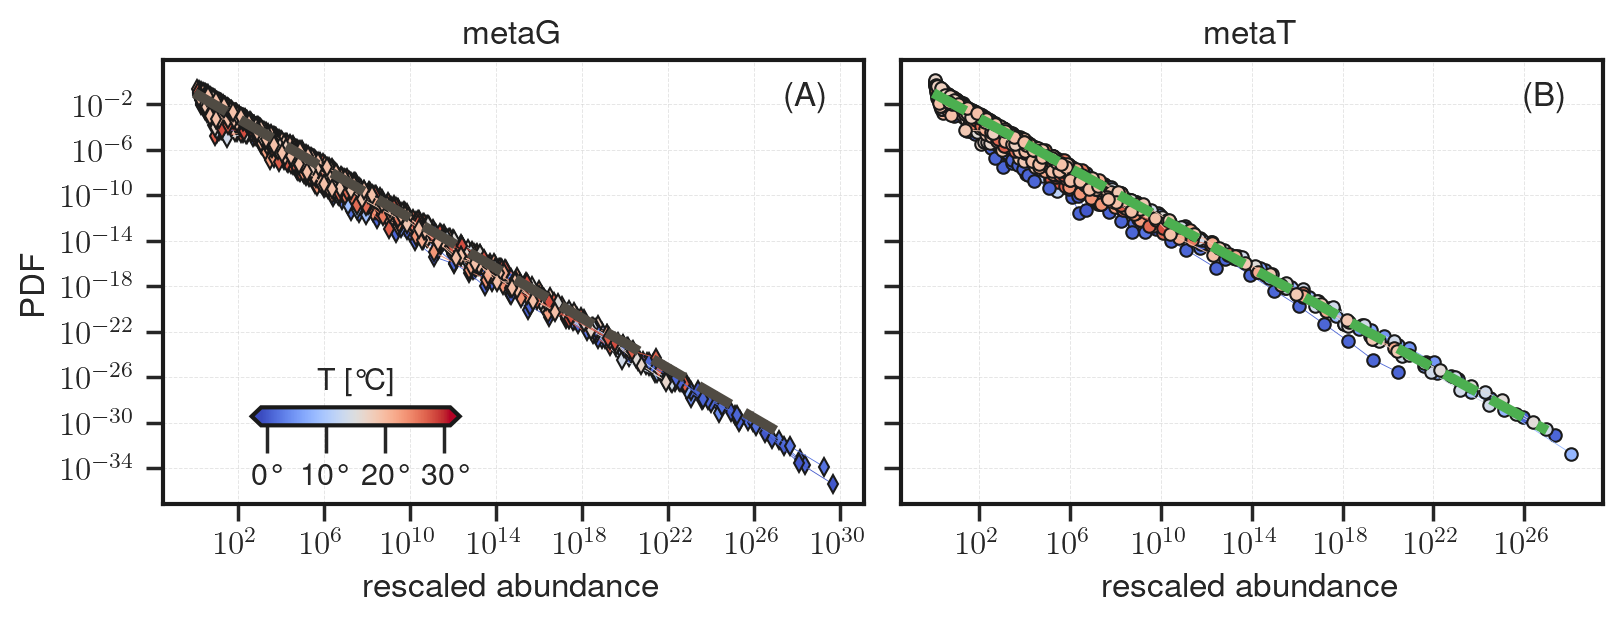

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(8,3), constrained_layout=True, gridspec_kw={'hspace': 0.5}, sharey=True)
labelsize=12

for i_ax, ax in enumerate(axes.flatten()):
    # set font size of the axes to 12
    ax.tick_params(axis='both', which='major', labelsize=labelsize)
    ax.set_xscale('log')
    ax.set_yscale('log')
    if i_ax % 4 == 0:
        ax.set_ylabel('PDF', fontsize=labelsize)
    if i_ax >= 0:
        ax.set_xlabel('rescaled abundance', fontsize=labelsize)
    if i_ax < 4:
        if i_ax % 2 == 0:
            ax.set_title('metaG', fontsize=labelsize)
            text = '(A)'
            ax.text(0.95, 0.95, text, transform=ax.transAxes, ha='right', va='top', fontsize=12)
            
            cax = fig.add_axes([0.15, 0.31, 0.13, 0.03])
            cax.tick_params(labelsize=10, size=10)
            sm = plt.cm.ScalarMappable(cmap=palettename, norm=plt.Normalize(vmin=-1, vmax=31))
            sm._A = []
            cbar = fig.colorbar(sm, cax=cax, ticks=[0., 10., 20., 30.], orientation='horizontal', extend='both')#, fraction=0.026, pad=-0.2)
            cbar.ax.set_xticklabels(['0°', '10°', '20°', '30°'],  font='Avenir', fontsize=11)
            cbar.ax.set_title('T [°C]', font='Avenir', fontsize=11)
        else:
            ax.set_title('metaT', fontsize=labelsize)
            text = '(B)'
            ax.text(0.95, 0.95, text, transform=ax.transAxes, ha='right', va='top', fontsize=12)
    ax.grid(True, lw=0.35, ls='--', alpha=0.5)
    if DATA_NORMALIZATION == "raw":
        ax.set_xlim(1e0, 1e6)
    
    # ax.xaxis.set_minor_locator(plt.LogLocator(base=10.0, subs=np.arange(2, 10) * 0.1, numticks=10))
    # ax.yaxis.set_minor_locator(plt.LogLocator(base=10.0, subs=np.arange(2, 10) * 0.1, numticks=10))
    
    ax.xaxis.set_minor_locator(LogLocator(base=10.0, subs=[], numticks=10))  # No minor ticks
    #ax.xaxis.set_minor_formatter(NullFormatter())   

    # Customize grid
    ax.xaxis.set_major_locator(LogLocator(base=10.0, numticks=10))
    ax.yaxis.set_major_locator(LogLocator(base=10.0, numticks=10))
    ax.xaxis.set_major_formatter(LogFormatterMathtext())
    ax.yaxis.set_major_formatter(LogFormatterMathtext())
    
    if DATA_NORMALIZATION == "raw":
        alpha = 1.0
        text = r'$y \sim x^{-%.0f}$' % (alpha+1)
        ax.text(0.5, 0.7, text, transform=ax.transAxes, ha='center', va='center', fontsize=12)
    
    

for i, station in enumerate(df_meta['metaT'].sample(frac=1, random_state=2).columns[::-1]):

    for meta in ['metaT', 'metaG']:
        df = df_meta[meta]
        data = df[station]
        fit = df_fits[meta].loc[station]
        if DATA_NORMALIZATION == "raw":
            k, alpha, gamma, mu = 10**fit['logk'], fit['alpha'], 1, fit['mu_KS']
            data = data[~data.isna()]
            data = data[data >= mu]
            color = return_color_station(station, metadata, palette_temp=palette_temp)
            data_rescaled = ((data + k - mu) / k) ** alpha
        elif DATA_NORMALIZATION == "norm":
            k, alpha, beta, mu = 10**fit['logk'], fit['alpha'], fit['beta'], fit['nmin']
            data = data[~data.isna()]
            data = data[data >= mu]
            color = return_color_station(station, metadata, palette_temp=palette_temp)
            data_rescaled = ((data + k) / k) ** (beta+alpha)

        x, y = plot_logSAD(data_rescaled, nbins=20)
        if meta == 'metaT':
            ax = axes[1]
        else:
            ax = axes[0]
            
            
        sns.lineplot(x=x, y=y, ax=ax, color=color, lw=0.3, marker=metamarker[meta], markersize=4.5, markeredgecolor='k')
        
        if i == 0:     
            if DATA_NORMALIZATION == "raw":
                if meta=='metaT':
                    xplot = np.logspace(0, 4.5, 100)
                else:
                    xplot = np.logspace(0, 5.5, 100)
                yplot = 1*xplot**(-2)
            elif DATA_NORMALIZATION == "norm":
                xplot = np.logspace(0, 27, 100)
                yplot = 1e-1*xplot**(-1.1)
            sns.lineplot(x=xplot, y=yplot, ax=ax, color=metacolor[meta], lw=3.6, ls='--', zorder=10)

figname = f"../figures/{DATA_NORMALIZATION}/SM/SADs_rescaled_all"
os.makedirs(os.path.dirname(figname), exist_ok=True)
for fmt in [".pdf", ".png"]:
    plt.savefig(f"{figname}{fmt}", dpi=300, bbox_inches="tight", transparent=True)

# figname = 'figures/thesis/SADs_rescaled_all.png'
# os.makedirs('figures/thesis/', exist_ok=True)
# fig.savefig(figname, dpi=300, bbox_inches='tight')

# Figure S8

mean = 0.05237661717970675, meanlog = 0.04678695653236614
error on the mean = 0.0031396731497878357
slope = -0.14811867709180912, intercept = -2.5508329118716633, r_value = -0.0386414209508723, p_value = 0.738639401512385, std_err = 0.4422844054915229


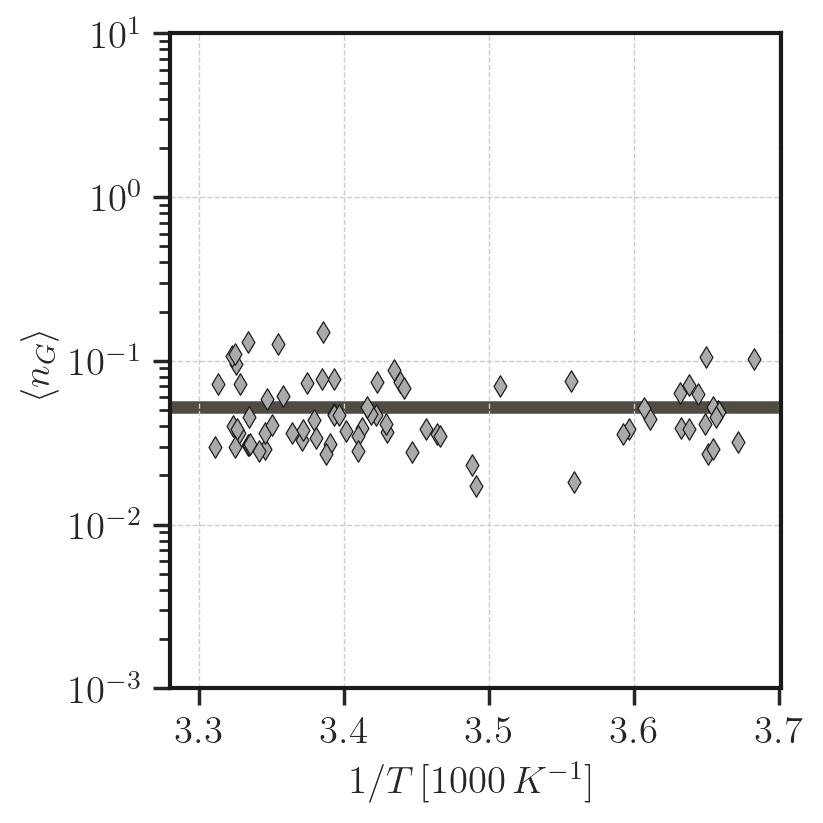

In [ ]:
fig, ax = plt.subplots(figsize=(4, 4), constrained_layout=True)

ax.yaxis.set_minor_locator(plt.LogLocator(base=10.0, subs=np.arange(2, 10) * 0.1, numticks=10))

# Customize grid
#ax.xaxis.set_major_locator(LogLocator(base=10.0, numticks=10))
ax.yaxis.set_major_locator(LogLocator(base=10.0, numticks=10))
ax.xaxis.set_major_formatter(ScalarFormatter())
ax.yaxis.set_major_formatter(LogFormatterMathtext())


ax.set_yscale('log')
# ax.set_ylim(1e-2, 1e3)
ax.set_xticks(np.arange(3.3, 3.8, 0.1))
ax.set_xlim(3.28, 3.701)
ax.set_xlabel(r'$1/T\, [1000\, K^{-1}]$' )
ax.set_ylabel(r'$t_0(T)/\gamma_1(T)$ fit' )


y = df_meta['metaG'].fillna(0).sum(axis=0)/df_meta['metaG'].fillna(0).astype(bool).sum(axis=0)
x = metadata.loc[y.index, 'inverseTemperature']
ymean = y.mean()
ymeanlog = np.exp(np.mean(np.log(y)))
print(f'mean = {ymean}, meanlog = {ymeanlog}')
# error on the mean
std = y.std()
error_mean = std/np.sqrt(len(y))
print(f'error on the mean = {error_mean}')

logy = np.log(y)
slope, intercept, r_value, p_value, std_err = linregress(x, logy)
print(f'slope = {slope}, intercept = {intercept}, r_value = {r_value}, p_value = {p_value}, std_err = {std_err}')

# sns.lineplot(x=x, y=np.exp(intercept + slope*x), ax=ax, color='k', lw=3.5, ls='--', zorder=0)

ax.axhline(ymean, color=metaGcolor, lw=4.5, ls='-', zorder=0)
#ax.axhline(ymean+2*std, color=metaGcolor, lw=1.5, ls='--', zorder=0)
#ax.axhline(ymean-1.*std, color=metaGcolor, lw=1.5, ls='--', zorder=0)

sns.scatterplot(x=x, y=y, ax=ax, color='#AAAAAA', edgecolor='k', s=30, marker='d')

ax.set_ylabel(r'$\langle n_{G} \rangle$')

ax.set_ylim(1e-3, 1e1)
ax.grid(True, which='major', linestyle='--', lw=0.5)

#ax.legend()
figname = f"../figures/{DATA_NORMALIZATION}/SM/mean_n_metaG"
os.makedirs(os.path.dirname(figname), exist_ok=True)
for fmt in [".pdf", ".png"]:
    plt.savefig(f"{figname}{fmt}", dpi=300, bbox_inches="tight", transparent=True)

# figname = 'figures/SM/mean_n_metaG.png'
# os.makedirs(os.path.dirname(figname), exist_ok=True)
# fig.savefig(figname, dpi=300, bbox_inches='tight')

In [ ]:
pd.DataFrame({'inverse_T': x, 'mean_metaG': y}).to_csv('mean_n_metaG_vs_invT.csv', index=True)

In [ ]:
metadata.loc[metadata['temp_woa'] < 0, 'temp_woa'] = 0

# Figure S9

slopeT = 10.853660071590227, interceptT = -29.964850661506496, r_valueT = 0.7505763193185728, p_valueT = 3.8703478003013266e-15, std_errT = 1.1033418520770593
interceptT = 9.692386112313052e-14, std_intercept = 3.6200194382433315
2.5958299580134075e-15 3.618971584026757e-12
Energies for metaT: 0.94+-0.10 eV
energy_richness = 0.94 eV, richness_S0 = 9.69e-14+-1.41e-13


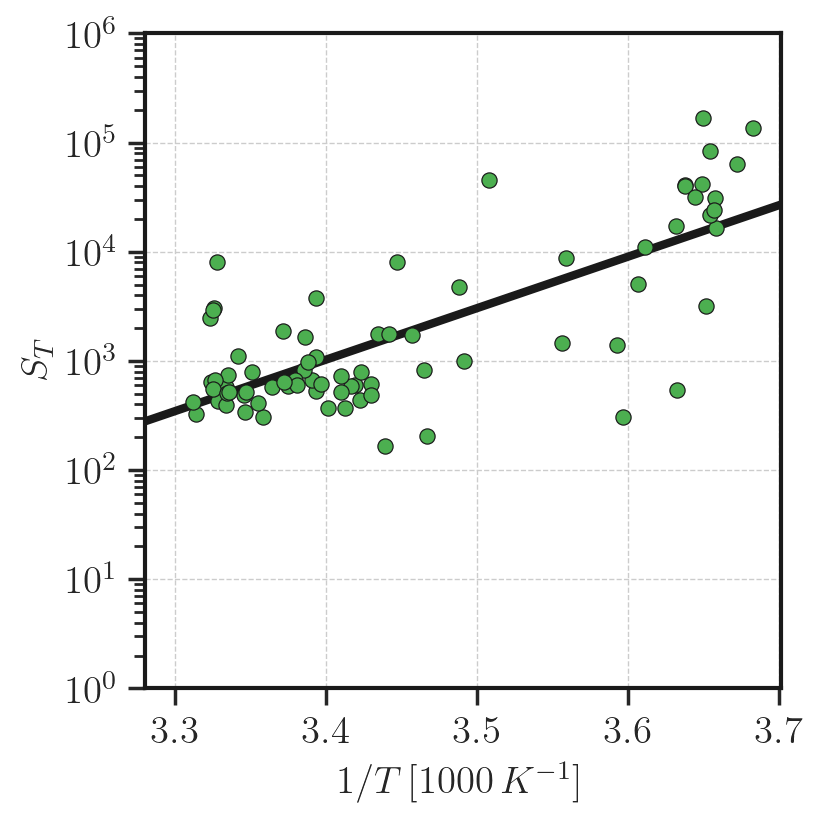

In [ ]:
fig, ax = plt.subplots(figsize=(4, 4), constrained_layout=True)

ax.set_yscale('log')
ax.set_ylim(1e0, 1e6)
ax.set_xticks(np.arange(3.3, 3.8, 0.1))
ax.set_xlim(3.28, 3.701)
ax.set_xlabel(r'$1/T\, [1000\, K^{-1}]$' )
ax.set_ylabel(r'$S_{T}$')
ax.yaxis.set_minor_locator(plt.LogLocator(base=10.0, subs=np.arange(2, 10) * 0.1, numticks=10))
ax.grid(True, which='major', linestyle='--', lw=0.5)
# Customize grid
#ax.xaxis.set_major_locator(LogLocator(base=10.0, numticks=10))
ax.yaxis.set_major_locator(LogLocator(base=10.0, numticks=10))
ax.xaxis.set_major_formatter(ScalarFormatter())
ax.yaxis.set_major_formatter(LogFormatterMathtext())



x = metadata['inverseTemperature']
yT = df_meta['metaT'].fillna(0).astype(bool).sum(axis=0)
# select only the temperatures for which we have data for both metaT and metaG
x = x.loc[yT.index]

sns.scatterplot(x=x, y=yT, ax=ax, color=metaTcolor, edgecolor='k', s=30, zorder=2)

logyT = np.log(yT)
slopeT, interceptT, r_valueT, p_valueT, std_errT = stats.linregress(x, logyT)
print(f'slopeT = {slopeT}, interceptT = {interceptT}, r_valueT = {r_valueT}, p_valueT = {p_valueT}, std_errT = {std_errT}')

xmean = np.mean(x)
std_intercept = std_errT * np.sqrt(1/len(x) + xmean**2/np.sum((x-xmean)**2))
print(f'interceptT = {np.exp(interceptT)}, std_intercept = {std_intercept}')
print(np.exp(interceptT-std_intercept), np.exp(interceptT+std_intercept))


x_plot = np.linspace(3.28, 3.701, 100)
y_plot = np.exp(slopeT*x_plot+interceptT)
sns.lineplot(x=x_plot, y=y_plot, ax=ax, color='k', ls='-', zorder=1, lw=3)

K_boltmann = 8.617333262145e-5 # in eV/K
ET = slopeT*K_boltmann*1e3
sigma_ET = std_errT*K_boltmann*1e3
n = len(x)
x_mean = np.mean(x)
std_err_intercept = std_err * np.sqrt(np.sum(x**2) / (n * np.sum((x - x_mean)**2)))
print(f'Energies for metaT: {ET:1.2f}+-{sigma_ET:1.2f} eV')

energy_richness = ET
sigma_energy_richness = sigma_ET
richness_S0 = np.exp(interceptT)
sigma_richness_S0 = std_err_intercept * richness_S0
print(f'energy_richness = {energy_richness:1.2f} eV, richness_S0 = {richness_S0:1.2e}+-{sigma_richness_S0:1.2e}')

# figname = 'figures/SM/S_ifo_T_mT.png'
# os.makedirs(os.path.dirname(figname), exist_ok=True)
# fig.savefig(figname, dpi=300, bbox_inches='tight')

# Heaps scaling theory

In [ ]:
# input
S_metaT = df_meta['metaT'].fillna(0).astype(bool).sum(axis=0)
N_metaT = df_meta['metaT'].fillna(0).sum(axis=0)
colors = metadata.loc[S_metaT.index, 'color']

# data
N_metaG = df_meta['metaG'].fillna(0).sum(axis=0)
S_metaG = df_meta['metaG'].fillna(0).astype(bool).sum(axis=0)
k_metaT = df_fits['metaT']['k_model']
k_metaG = df_fits['metaG']['k_model']

## Temperature sensitivity of transcription efficiency

In [ ]:
x = gdf['inverseTemperature']
y = gdf['kT/kG'] # transcription efficiency
x = x[y > 0]
y = y[y > 0]

slope, intercept, r_value, p_value, std_err = stats.linregress(x, np.log(y))
K_boltzmann = 8.617333262145e-5 # in eV/K
E = slope * K_boltzmann * 1e3
sigma_E = std_err * K_boltzmann * 1e3

sensitivity_transcription_efficiency = E
sigma_sensitivity_transcription_efficiency = sigma_E

n = len(x)
x_mean = np.mean(x)
std_err_intercept = std_err * np.sqrt(1/n + x_mean**2/np.sum((x - x_mean)**2))
r_over_gamma_inf = np.exp(intercept)
std_upper_r_over_gamma_inf = np.exp(intercept + std_err_intercept) # the normality assumption is not valid here, so we use the exponential of the intercept plus the standard error
std_lower_r_over_gamma_inf = np.exp(intercept - std_err_intercept)


print(f"Temperature sensitivity of transcription efficiency: {E:1.2f}±{sigma_E:1.2f} eV. p-value={p_value:1.4f}")
print(f"r/gamma_inf: {r_over_gamma_inf:1.2e}. C.I.: upper: {std_upper_r_over_gamma_inf:1.2e} lower: {std_lower_r_over_gamma_inf:1.2e} (n={n})")


Temperature sensitivity of transcription efficiency: 0.42±0.14 eV. p-value=0.0041
r/gamma_inf: 1.27e-07. C.I.: upper: 3.00e-05 lower: 5.37e-10 (n=77)


Energies for metaG: 0.42+-0.14 eV. p-value=0.0041
to/gamma1=1.2695958057776375e-07
1.0000006939848052 -15.879397064311505
activation energy: 0.42+-0.14 eV
t0/gamma1: 1.27e-07+-6.94e-07
5.366998381680338e-10 3.0033053774529218e-05


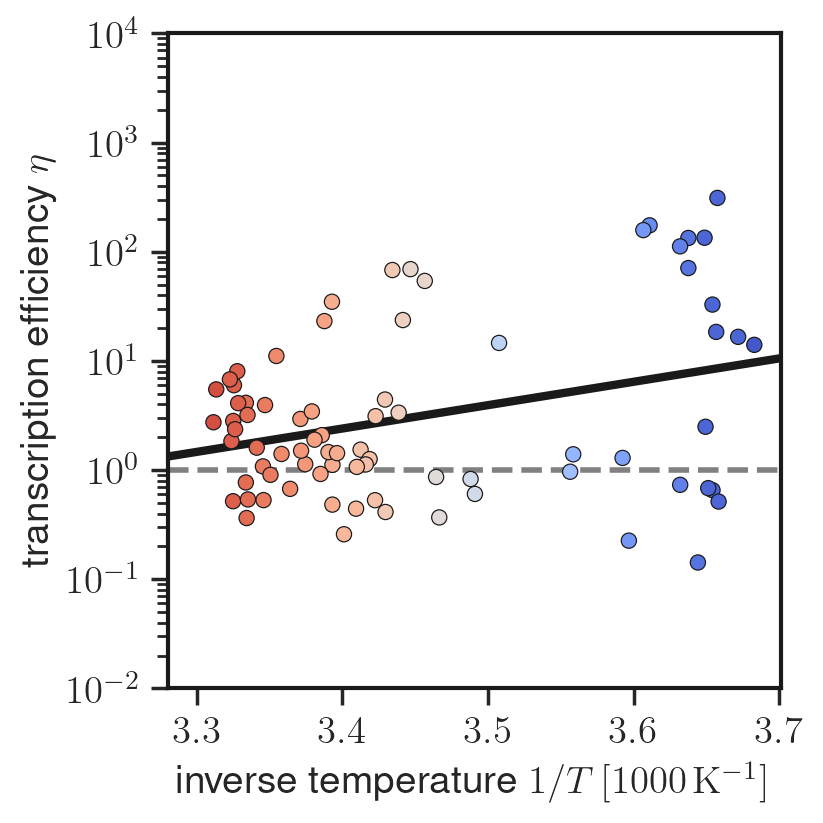

In [ ]:
fig, ax = plt.subplots(figsize=(4, 4), constrained_layout=True)

ax.set_facecolor("white") 
ax.set_yscale('log')
ax.set_ylim(1e-2, 1e4)
ax.set_xticks(np.arange(3.3, 3.8, 0.1))
ax.set_xlim(3.28, 3.701)
ax.set_xlabel(r'inverse temperature $1/T\, [1000\, \mathrm{K}^{-1}]$' )
ax.set_ylabel(r'transcription efficiency $\eta$' )
ax.yaxis.set_minor_locator(plt.LogLocator(base=10.0, subs=np.arange(2, 10) * 0.1, numticks=10))
ax.yaxis.set_major_locator(LogLocator(base=10.0, numticks=10))
ax.xaxis.set_major_formatter(ScalarFormatter())
ax.yaxis.set_major_formatter(LogFormatterMathtext())

sns.scatterplot(x='inverseTemperature', y='kT/kG', data=gdf, ax=ax, palette=None, hue=None, s=30, edgecolor='k', alpha=1, zorder=3, c=gdf['color'].tolist())

x = gdf['inverseTemperature']
y = gdf['kT/kG']
x = x[y > 0]
y = y[y > 0]

slope, intercept, r_value, p_value, std_err = stats.linregress(x, np.log(y))
K_boltmann = 8.617333262145e-5 # in eV/K
E = slope*K_boltmann*1e3
sigma_E = std_err*K_boltmann*1e3
print(f'Energies for {meta}: {E:1.2f}+-{sigma_E:1.2f} eV. p-value={p_value:1.4f}')
print(f'to/gamma1={np.exp(intercept)}')

y_fit = np.exp(slope*x + intercept)
xx = np.linspace(3.28, 3.7, 100)
yy = np.exp(slope*xx + intercept)
sns.lineplot(x=xx, y=yy, ax=ax, color='k', ls='-', zorder=2, lw=3)

ax.axhline(1, color='gray', ls='--', lw=2, zorder=1)

activation_energy = E
sigma_activation_energy = sigma_E
t0_over_gamma1 = np.exp(intercept)
n = len(x)
x_mean = np.mean(x)
std_err_intercept = std_err * np.sqrt(1/n + x_mean**2/np.sum((x - x_mean)**2))
std_t0_over_gamma1 = t0_over_gamma1 * std_err_intercept
print(np.exp(std_t0_over_gamma1), intercept)

print(f'activation energy: {activation_energy:1.2f}+-{sigma_E:1.2f} eV')
print(f't0/gamma1: {t0_over_gamma1:1.2e}+-{std_t0_over_gamma1:1.2e}')

print(np.exp(intercept - std_err_intercept), np.exp(intercept + std_err_intercept))

## Temperature sensitivity of transcription richness

In [ ]:
x = gdf['inverseTemperature']
y = df_meta['metaT'].fillna(0).astype(bool).sum(axis=0) # transcription richness
x = x[y > 0]
y = y[y > 0]

logy = np.log(y)
slopeT, interceptT, r_valueT, p_valueT, std_errT = stats.linregress(x, logy)

K_boltzmann = 8.617333262145e-5 # in eV/K
epsilon = slopeT*K_boltzmann*1e3
sigma_epsilon = std_errT*K_boltzmann*1e3

sensitivity_transcription_richness = epsilon
sigma_sensitivity_transcription_richness = sigma_epsilon

n = len(x)
x_mean = np.mean(x)
std_err_intercept = std_err * np.sqrt(np.sum(x**2) / (n * np.sum((x - x_mean)**2)))
S_inf = np.exp(interceptT)
std_upper_S_inf = np.exp(interceptT + std_err_intercept)  # the normality assumption is not valid here, so we use the exponential of the intercept plus the standard error
std_lower_S_inf = np.exp(interceptT - std_err_intercept)

print(f"Temperature sensitivity of transcription richness: {epsilon:1.2f}±{sigma_epsilon:1.2f} eV. p-value={p_valueT:1.4f}")
print(f"S_inf: {S_inf:1.2e}. C.I.: upper: {std_upper_S_inf:1.2e} lower: {std_lower_S_inf:1.2e} (n={n})")

Temperature sensitivity of transcription richness: 0.94±0.10 eV. p-value=0.0000
S_inf: 9.69e-14. C.I.: upper: 2.29e-11 lower: 4.10e-16 (n=77)


## Heaps prediction

In [ ]:
K_inv = (N_metaG/S_metaG).mean() * r_over_gamma_inf * S_inf**(-E/epsilon)
eta = 1+E/epsilon
sigma_eta = np.sqrt((1+1/energy_richness)**2 * sigma_E**2 + (1-sigma_E/epsilon**2)**2 * sigma_epsilon**2)

xi = 1/eta
sigma_xi = sigma_eta/eta**2
print(f'xi : {xi:1.2f}±{sigma_xi:1.2f}')
print(f'K_inv : {K_inv:1.2e}')
print(f'K : {1/K_inv:1.2e}')

xi : 0.69±0.15
K_inv : 5.39e-03
K : 1.85e+02


fitted xi: 0.77±0.03
predicted xi: 0.69±0.15


<Axes: xlabel='$N$', ylabel='$S$'>

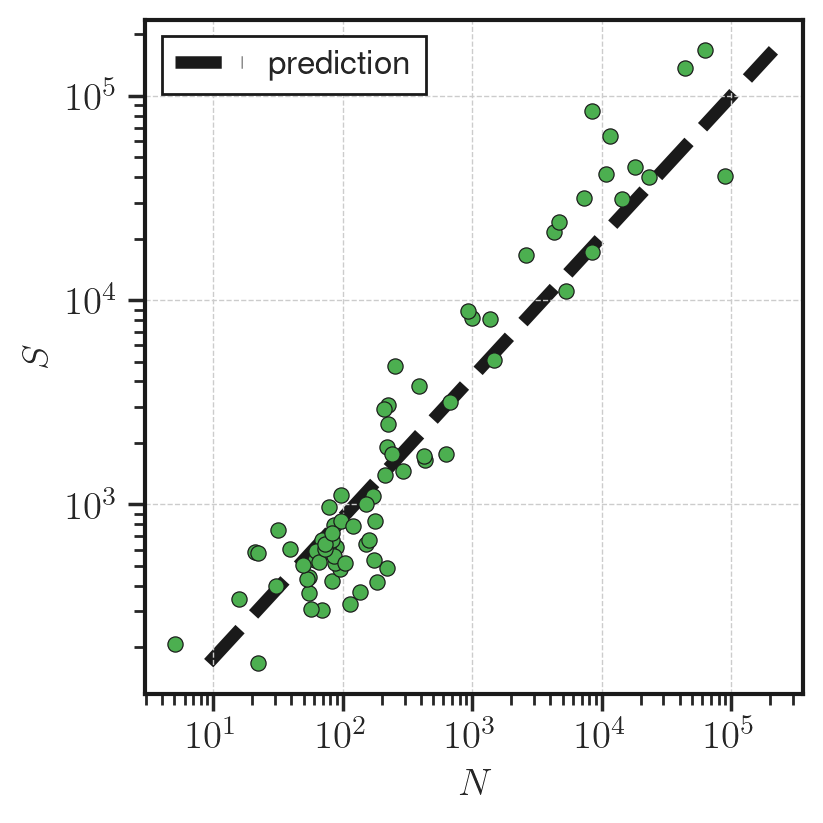

In [ ]:
N_metaT_pred = (N_metaG/S_metaG).mean() * S_metaT**(1+E/epsilon) * r_over_gamma_inf * S_inf**(-E/epsilon)
N_metaT = df_meta['metaT'].fillna(0).sum(axis=0)

fig, ax = plt.subplots(figsize=(4, 4), constrained_layout=True)
ax.grid(True, which='major', linestyle='--', lw=0.5)
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel(r'$N$')
ax.set_ylabel(r'$S$')

sns.scatterplot(y=S_metaT, x=N_metaT, ax=ax, color=metaTcolor, edgecolor='k', s=30, marker='o')

logy = np.log10(S_metaT)
logx = np.log10(N_metaT)
slope, intercept, r_value, p_value, std_err = linregress(logx, logy)
# print(f'slope = {slope}, intercept = {intercept}, r_value = {r_value}, p_value = {p_value}, std_err = {std_err}')
print(f"fitted xi: {slope:1.2f}±{std_err:1.2f}")
print(f"predicted xi: {xi:1.2f}±{sigma_xi:1.2f}")

label = 'prediction'
x_plot = np.logspace(np.log10(N_metaT_pred.min()), np.log10(N_metaT_pred.max()), 100)
y_plot = (x_plot/K_inv)**(1/eta)
sns.lineplot(x=x_plot, y=y_plot, ax=ax, color='k', ls='--', zorder=0, lw=4.5, label=label)

# Figures SM review

## 1. Exponential cut-off term

In [ ]:
BIC_data = pd.read_csv('../fit/BIC_micro_SRF_bacilla.csv', index_col=0)
BIC_data["BIC_ratio"] = BIC_data["BIC_par"] / BIC_data["BIC_exp"]
display(BIC_data.head())
display(BIC_data.tail())

# print how many stations have BIC_ratio < 1 (for metaG and for metaT)
n_bic_metaG = (BIC_data.loc['metaG', 'BIC_ratio'] < 1).sum()
n_bic_metaT = (BIC_data.loc['metaT', 'BIC_ratio'] < 1).sum()
print(f'Number of stations with BIC_ratio < 1 for metaG: {n_bic_metaG} out of {BIC_data.shape[0]/2} (percentage: {n_bic_metaG/(BIC_data.shape[0]/2)*100:1.2f}%)')
print(f'Number of stations with BIC_ratio < 1 for metaT: {n_bic_metaT} out of {BIC_data.shape[0]/2} (percentage: {n_bic_metaT/(BIC_data.shape[0]/2)*100:1.2f}%)')

FileNotFoundError: [Errno 2] No such file or directory: '../fit/BIC_micro_SRF_bacilla.csv'

In [ ]:
# Impostazioni generali
figsize = (8, 3)
labelsize = 12
# plt.rcParams['text.usetex'] = True

fig, axes = plt.subplots(1, 2, figsize=figsize, constrained_layout=True, 
                         gridspec_kw={'wspace': 0.1}, sharey=True)

targets = ['metaG', 'metaT']

for i_ax, ax in enumerate(axes.flatten()):
    target = targets[i_ax]
    
    # --- STYLING (Adattato dal tuo snippet) ---
    ax.tick_params(axis='both', which='major', labelsize=labelsize)
    
    # Nota: Manteniamo scala lineare per i BIC, diverso dai SAD
    # ax.set_xscale('log') 
    # ax.set_yscale('log')
    
    # Griglia personalizzata
    ax.grid(True, lw=0.35, ls='--', alpha=0.5)
    
    # Titoli e Annotazioni (A)/(B)
    if i_ax == 0:
        ax.set_title('metaG', fontsize=labelsize)
        ax.text(0.95, 0.95, '(A)', transform=ax.transAxes, ha='right', va='top', fontsize=12)
        ax.set_ylabel(r'$\textrm{BIC} / \textrm{BIC}_{\beta}$', fontsize=labelsize)
        
        # --- COLORBAR PERSONALIZZATA (Inserita come nello snippet) ---
        # Le coordinate potrebbero richiedere piccoli aggiustamenti fini a seconda dei margini esatti
        cax = fig.add_axes([0.12, 0.82, 0.15, 0.04]) 
        cax.tick_params(labelsize=8, size=2) # Ridotto leggermente per lo spazio
        # Assumo che 'palettename' sia definito nel tuo ambiente, es: 'RdYlBu_r' o simile
        # Se non è definito, sostituisci 'palettename' con una stringa, es: 'viridis'
        sm = plt.cm.ScalarMappable(cmap=palettename if 'palettename' in locals() else 'viridis', 
                                   norm=plt.Normalize(vmin=-1, vmax=31))
        sm._A = []
        cbar = fig.colorbar(sm, cax=cax, ticks=[0., 10., 20., 30.], orientation='horizontal', extend='both')
        cbar.ax.set_xticklabels(['0°', '10°', '20°', '30°'], font='Avenir', fontsize=9) 
        cbar.ax.set_title('T [°C]', font='Avenir', fontsize=9, pad=4)

    else:
        ax.set_title('metaT', fontsize=labelsize)
        ax.text(0.95, 0.95, '(B)', transform=ax.transAxes, ha='right', va='top', fontsize=12)
        # Rimuovi etichette asse Y per il secondo pannello (sharey)
        ax.tick_params(labelleft=False)

    # --- DATI E PLOT ---
    # Recupero i dati specifici
    df_plot = BIC_data.loc[target].copy()
    
    # Calcolo il rapporto (assumendo BIC_par numeratore, BIC_exp denominatore come da screenshot)
    df_plot['ratio'] = df_plot['BIC_par'] / df_plot['BIC_exp']
    
    # Linea di riferimento
    ax.axhline(1, color='red', linestyle='--', lw=2.5, zorder=1)
    
    # Plot dei punti con i colori delle stazioni
    stations = df_plot['station'].values
    ratios = df_plot['ratio'].values
    
    for j, station in enumerate(stations):
        c = return_color_station(station, metadata, palette_temp=palette_temp)
        # Usiamo str(station) per mantenere l'asse categorico
        ax.scatter(str(station), ratios[j], color=c, s=30, zorder=10, edgecolors='k', marker=metamarker[target])

    # Ruota le etichette delle stazioni per leggibilità
    ax.tick_params(axis='x', rotation=90, labelsize=3)
    
    # Imposta limiti Y se necessario per centrare la visualizzazione (opzionale)
    ax.set_ylim(0.996, 1.004)

plt.savefig('figures/SM/BIC_comparison_styled.png', dpi=300, bbox_inches='tight')
plt.show()

: 

In [ ]:
figsize = (8, 3)
labelsize = 12
# plt.rcParams['text.usetex'] = True

fig, axes = plt.subplots(1, 2, figsize=figsize, constrained_layout=True, 
                         gridspec_kw={'wspace': 0.1}, sharey=True)


targets = ['metaG', 'metaT']

for i_ax, ax in enumerate(axes.flatten()):
    target = targets[i_ax]
    bins = np.arange(0, 3.5, 0.2)
    
    sns.histplot(BIC_data.loc[target, 'alpha_par'], bins=bins, kde=False, ax=ax, color=metacolor[target], edgecolor='k')
    sns.histplot(BIC_data.loc[target, 'alpha_exp'], bins=bins, kde=False, ax=ax, color='gray', edgecolor='k', alpha=0.5)
    
    # sns.scatterplot(x=BIC_data.loc[target, 'alpha_par'], y=BIC_data.loc[target, 'alpha_exp'], ax=ax, color=metacolor[target], edgecolor='k', s=50, marker=metamarker[target])
    
    # # 1:1 line
    # xlims = ax.get_xlim()
    # ylims = ax.get_ylim()
    # lims = [max(xlims[0], ylims[0]), min(xlims[1], ylims[1])]
    # ax.plot(lims, lims, 'k--', lw=2.5, zorder=0)
    # ax.set_xlim(lims)
    # ax.set_ylim(lims)

: 

In [ ]:
# Impostazioni generali
figsize = (8, 3)
labelsize = 12
# plt.rcParams['text.usetex'] = True

fig, axes = plt.subplots(1, 2, figsize=figsize, constrained_layout=True, 
                         gridspec_kw={'wspace': 0.1}, sharey=True)

targets = ['metaG', 'metaT']

for i_ax, ax in enumerate(axes.flatten()):
    target = targets[i_ax]
    
    # --- STYLING (Adattato dal tuo snippet) ---
    ax.tick_params(axis='both', which='major', labelsize=labelsize)
    
    # Nota: Manteniamo scala lineare per i BIC, diverso dai SAD
    # ax.set_xscale('log') 
    # ax.set_yscale('log')
    
    # Griglia personalizzata
    ax.grid(True, lw=0.35, ls='--', alpha=0.5)
    
    # Titoli e Annotazioni (A)/(B)
    if i_ax == 0:
        ax.set_title('metaG', fontsize=labelsize)
        ax.text(0.95, 0.95, '(A)', transform=ax.transAxes, ha='right', va='top', fontsize=12)
        ax.set_ylabel(r'exponential cutoff $1 /\beta$', fontsize=labelsize)
        
        # --- COLORBAR PERSONALIZZATA (Inserita come nello snippet) ---
        # Le coordinate potrebbero richiedere piccoli aggiustamenti fini a seconda dei margini esatti
        cax = fig.add_axes([0.12, 0.82, 0.15, 0.04]) 
        cax.tick_params(labelsize=8, size=2) # Ridotto leggermente per lo spazio
        # Assumo che 'palettename' sia definito nel tuo ambiente, es: 'RdYlBu_r' o simile
        # Se non è definito, sostituisci 'palettename' con una stringa, es: 'viridis'
        sm = plt.cm.ScalarMappable(cmap=palettename if 'palettename' in locals() else 'viridis', 
                                   norm=plt.Normalize(vmin=-1, vmax=31))
        sm._A = []
        cbar = fig.colorbar(sm, cax=cax, ticks=[0., 10., 20., 30.], orientation='horizontal', extend='both')
        cbar.ax.set_xticklabels(['0°', '10°', '20°', '30°'], font='Avenir', fontsize=9) 
        cbar.ax.set_title('T [°C]', font='Avenir', fontsize=9, pad=4)

    else:
        ax.set_title('metaT', fontsize=labelsize)
        ax.text(0.95, 0.95, '(B)', transform=ax.transAxes, ha='right', va='top', fontsize=12)
        # Rimuovi etichette asse Y per il secondo pannello (sharey)
        ax.tick_params(labelleft=False)

    # --- DATI E PLOT ---
    # Recupero i dati specifici
    df_plot = BIC_data.loc[target].copy()
    df_plot['BIC_ratio'] = df_plot['BIC_par'] / df_plot['BIC_exp']
    
    # Calcolo il rapporto (assumendo BIC_par numeratore, BIC_exp denominatore come da screenshot)
    df_plot['ratio'] = (1. / 10**df_plot['logb_exp'])
    
    # Linea di riferimento
    # ax.axhline(1, color='red', linestyle='--', lw=2.5, zorder=1)

    
    # Plot dei punti con i colori delle stazioni
    stations = df_plot['station'].values
    ratios = df_plot['ratio'].values
    BIC_ratios = df_plot['BIC_ratio'].values
    
    for j, station in enumerate(stations):
        c = return_color_station(station, metadata, palette_temp=palette_temp)
        # Usiamo str(station) per mantenere l'asse categorico
        if BIC_ratios[j] < 1.0:
            ax.scatter(str(station), ratios[j], color=c, s=30, zorder=10, edgecolors='k', marker=metamarker[target], alpha=0.3)
        else:
            ax.scatter(str(station), ratios[j], color=c, s=30, zorder=10, edgecolors='k', marker=metamarker[target])

    # Ruota le etichette delle stazioni per leggibilità
    ax.tick_params(axis='x', rotation=90, labelsize=3)
    
    # Imposta limiti Y se necessario per centrare la visualizzazione (opzionale)
    # ax.set_ylim(0.996, 1.004)
    ax.set_yscale('log')

plt.savefig('figures/SM/BIC_exp_beta_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

: 

In [ ]:
# Impostazioni generali
figsize = (8, 3)
labelsize = 12
# plt.rcParams['text.usetex'] = True

fig, axes = plt.subplots(1, 2, figsize=figsize, constrained_layout=True, 
                         gridspec_kw={'wspace': 0.1}, sharey=True)

targets = ['metaG', 'metaT']

for i_ax, ax in enumerate(axes.flatten()):
    target = targets[i_ax]
    
    # --- STYLING (Adattato dal tuo snippet) ---
    ax.tick_params(axis='both', which='major', labelsize=labelsize)
    
    # Nota: Manteniamo scala lineare per i BIC, diverso dai SAD
    # ax.set_xscale('log') 
    # ax.set_yscale('log')
    
    # Griglia personalizzata
    ax.grid(True, lw=0.35, ls='--', alpha=0.5)
    
    # Titoli e Annotazioni (A)/(B)
    if i_ax == 0:
        ax.set_title('metaG', fontsize=labelsize)
        ax.text(0.95, 0.95, '(A)', transform=ax.transAxes, ha='right', va='top', fontsize=12)
        ax.set_ylabel(r'power-law exponent $\alpha$', fontsize=labelsize)
        
        # --- COLORBAR PERSONALIZZATA (Inserita come nello snippet) ---
        # Le coordinate potrebbero richiedere piccoli aggiustamenti fini a seconda dei margini esatti
        cax = fig.add_axes([0.12, 0.82, 0.15, 0.04]) 
        cax.tick_params(labelsize=8, size=2) # Ridotto leggermente per lo spazio
        # Assumo che 'palettename' sia definito nel tuo ambiente, es: 'RdYlBu_r' o simile
        # Se non è definito, sostituisci 'palettename' con una stringa, es: 'viridis'
        sm = plt.cm.ScalarMappable(cmap=palettename if 'palettename' in locals() else 'viridis', 
                                   norm=plt.Normalize(vmin=-1, vmax=31))
        sm._A = []
        cbar = fig.colorbar(sm, cax=cax, ticks=[0., 10., 20., 30.], orientation='horizontal', extend='both')
        cbar.ax.set_xticklabels(['0°', '10°', '20°', '30°'], font='Avenir', fontsize=9) 
        cbar.ax.set_title('T [°C]', font='Avenir', fontsize=9, pad=4)

    else:
        ax.set_title('metaT', fontsize=labelsize)
        ax.text(0.95, 0.95, '(B)', transform=ax.transAxes, ha='right', va='top', fontsize=12)
        # Rimuovi etichette asse Y per il secondo pannello (sharey)
        ax.tick_params(labelleft=False)

    # --- DATI E PLOT ---
    # Recupero i dati specifici
    df_plot = BIC_data.loc[target].copy()
    
    # Linea di riferimento
    # ax.axhline(1, color='red', linestyle='--', lw=2.5, zorder=1)

    
    # Plot dei punti con i colori delle stazioni
    stations = df_plot['station'].values
    alphas = df_plot['alpha_exp'].values
    # BIC_ratios = df_plot['BIC_ratio'].values
    alphas_par = df_plot['alpha_par'].values
    
    
    for j, station in enumerate(stations):
        c = return_color_station(station, metadata, palette_temp=palette_temp)
        # Usiamo str(station) per mantenere l'asse categorico
        # ax.scatter(str(station), alphas_par[j], color='gray', s=10, zorder=5, edgecolors='k', marker='>', alpha=0.1)
        if BIC_ratios[j] < 1.0:
            ax.scatter(str(station), alphas[j], color=c, s=30, zorder=10, edgecolors='k', marker=metamarker[target], alpha=0.3)
        else:
            ax.scatter(str(station), alphas[j], color=c, s=30, zorder=10, edgecolors='k', marker=metamarker[target])

    # Ruota le etichette delle stazioni per leggibilità
    ax.tick_params(axis='x', rotation=90, labelsize=3)
    
    # Imposta limiti Y se necessario per centrare la visualizzazione (opzionale)
    ax.set_ylim(0., 3.5)
    # ax.set_yscale('log')

plt.savefig('figures/SM/BIC_exp_alpha_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

: 

In [ ]:
fit_metaT['mu_KS']

: 

In [ ]:
fig, ax = plt.subplots(figsize=(4, 4), constrained_layout=True)

# ax.set_facecolor("#EEEEEE") 
ax.set_yscale('log')
ax.set_ylim(1e-2, 1e4)
ax.set_xticks(np.arange(3.3, 3.8, 0.1))
ax.set_xlim(3.28, 3.701)
ax.set_xlabel(r'inverse temperature $1/T\, [1000\, \mathrm{K}^{-1}]$' )
ax.set_ylabel(r'transcription efficiency $\eta$' )
ax.yaxis.set_minor_locator(plt.LogLocator(base=10.0, subs=np.arange(2, 10) * 0.1, numticks=10))
ax.yaxis.set_major_locator(LogLocator(base=10.0, numticks=10))
ax.xaxis.set_major_formatter(ScalarFormatter())
ax.yaxis.set_major_formatter(LogFormatterMathtext())

gdf['kT_model_par'] = np.maximum(10**BIC_data.loc['metaT']["logk_par"].values - fit_metaT['mu_KS'], fit_metaT['mu_KS'])
gdf['kG_model_par'] = np.maximum(10**BIC_data.loc['metaG']["logk_par"].values - fit_metaG['mu_KS'], fit_metaG['mu_KS'])
gdf['kT_model_exp'] = np.maximum(10**BIC_data.loc['metaT']["logk_exp"].values - fit_metaT['mu_KS'], fit_metaT['mu_KS'])
gdf['kG_model_exp'] = np.maximum(10**BIC_data.loc['metaG']["logk_exp"].values - fit_metaG['mu_KS'], fit_metaG['mu_KS'])

gdf['eta_model_par'] = gdf['kT_model_par'] / gdf['kG_model_par']
gdf['eta_model_exp'] = gdf['kT_model_exp'] / gdf['kG_model_exp']
sns.scatterplot(x='inverseTemperature', y='eta_model_par', data=gdf, ax=ax, palette=None, hue=None, s=30, edgecolor='k', alpha=0.2, zorder=3, c='grey', marker='^')
sns.scatterplot(x='inverseTemperature', y='eta_model_exp', data=gdf, ax=ax, palette=None, hue=None, s=30, edgecolor='k', alpha=1, zorder=3, c=gdf['color'].tolist())
# sns.scatterplot(x='inverseTemperature', y='kT/kG', data=gdf, ax=ax, palette=None, hue=None, s=30, edgecolor='k', alpha=1, zorder=3, c=gdf['color'].tolist(), marker='>')

# linear fit on the log of y
x = gdf['inverseTemperature']
y = gdf['eta_model_exp']
x = x[y > 0]
y = y[y > 0]    
logy = np.log(y)
slope, intercept, r_value, p_value, std_err = linregress(x, logy)
K_boltzmann = 8.617333262145e-5 # in eV/K
E = slope * K_boltzmann * 1e3
sigma_E = std_err * K_boltzmann * 1e3   
print(f"Temperature sensitivity of transcription efficiency (BIC exp): {E:1.2f}±{sigma_E:1.2f} eV. p-value={p_value:1.4f}")
x_plot = np.linspace(3.28, 3.701, 100)
y_plot = np.exp(slope*x_plot+intercept)
# sns.lineplot(x=x_plot, y=y_plot, ax=ax, color='k', ls='-', zorder=1, lw=2)

x = gdf['inverseTemperature']
y = gdf['eta_model_par']
x = x[y > 0]
y = y[y > 0]    
logy = np.log(y)
slope, intercept, r_value, p_value, std_err = linregress(x, logy)
K_boltzmann = 8.617333262145e-5 # in eV/K
E = slope * K_boltzmann * 1e3
sigma_E = std_err * K_boltzmann * 1e3   
print(f"Temperature sensitivity of transcription efficiency (BIC par): {E:1.2f}±{sigma_E:1.2f} eV. p-value={p_value:1.4f}")
x_plot = np.linspace(3.28, 3.701, 100)
y_plot = np.exp(slope*x_plot+intercept)
sns.lineplot(x=x_plot, y=y_plot, ax=ax, color='grey', ls='--', zorder=1, lw=1, alpha=0.7)

x = gdf['inverseTemperature']
y = gdf['eta_model_exp']
x = x[y > 0]
y = y[y > 0]    
logy = np.log(y)
slope, intercept, r_value, p_value, std_err = linregress(x, logy)
K_boltzmann = 8.617333262145e-5 # in eV/K
E = slope * K_boltzmann * 1e3
sigma_E = std_err * K_boltzmann * 1e3   
print(f"Temperature sensitivity of transcription efficiency (BIC par): {E:1.2f}±{sigma_E:1.2f} eV. p-value={p_value:1.4f}")
x_plot = np.linspace(3.28, 3.701, 100)
y_plot = np.exp(slope*x_plot+intercept)
sns.lineplot(x=x_plot, y=y_plot, ax=ax, color='k', ls='-', zorder=1, lw=1.5, alpha=1)

plt.savefig('figures/SM/BIC_eta_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

: 

In [ ]:
gdf.columns

: 

In [ ]:
fig, ax = plt.subplots(figsize=(4, 4), constrained_layout=True)

sns.scatterplot(x='kT/kG', y='kT_kG_BIC_par', data=gdf, ax=ax, palette=None, hue=None, s=30, edgecolor='k', alpha=1, zorder=3, c=gdf['color'].tolist())
ax.set_xscale('log')
ax.set_yscale('log')
# 1:1 line
xlims = ax.get_xlim()
ylims = ax.get_ylim()
lims = [max(xlims[0], ylims[0]), min(xlims[1], ylims[1])]
ax.plot(lims, lims, 'k--', alpha=0.75, zorder=0)

: 

## 2. Ratio of metaG and metaT

In [ ]:
fname = '../data/summary_abundance_richness_micro_SRF_bacilla.csv'
fraction_of_bac = pd.read_csv(fname, index_col=5)
fraction_of_bac['S_ratio'] = fraction_of_bac['S_bac'] / fraction_of_bac['S']*100
fraction_of_bac['N_ratio'] = fraction_of_bac['N_bac'] / fraction_of_bac['N']*100
fraction_of_bac.head()

: 

In [ ]:


figsize = (8, 3)
labelsize = 12
# plt.rcParams['text.usetex'] = True

fig, axes = plt.subplots(1, 2, figsize=figsize, constrained_layout=True, 
                         gridspec_kw={'wspace': 0.1}, sharey=True)

# 1. Definiamo la lista ordinata delle stazioni (stringhe)
unique_stations = fraction_of_bac['station'].unique()
# Ordiniamo numericamente le stazioni
try:
    sorted_stations = sorted(unique_stations, key=lambda x: int(x))
except:
    sorted_stations = sorted(unique_stations)
    
# Convertiamo tutto in stringa per sicurezza
stations_order = [str(s) for s in sorted_stations]

for i_ax, ax in enumerate(axes.flatten()):
    target = targets[i_ax]

    ax.tick_params(axis='both', which='major', labelsize=labelsize)
    ax.grid(True, lw=0.35, ls='--', alpha=0.5)

    if i_ax == 0:
        ax.set_title('Abundance Ratio', fontsize=labelsize)
        ax.text(0.1, 0.95, '(A)', transform=ax.transAxes,
                ha='right', va='top', fontsize=12)
        ax.set_ylabel(r'$N_{\text{bac}}/N_{\text{total}}\ (\%)$', fontsize=labelsize)
        ycol = 'N_ratio'
    else:
        ax.set_title('Richness Ratio', fontsize=labelsize)
        ax.text(0.1, 0.95, '(B)', transform=ax.transAxes,
                ha='right', va='top', fontsize=12)
        ax.set_ylabel(r'$S_{\text{bac}}/S_{\text{total}}\ (\%)$', fontsize=labelsize)
        ycol = 'S_ratio'

    for meta in ['metaG', 'metaT']:
        df_plot = fraction_of_bac.loc[meta].copy()
        
        # --- FIX PRINCIPALE ---
        # 1. Convertiamo in stringa
        df_plot['station'] = df_plot['station'].astype(str)
        
        # 2. Trasformiamo in tipo 'Categorical' imponendo l'ordine
        # Questo dice a Seaborn/Matplotlib esattamente in che ordine mettere le stazioni sull'asse
        df_plot['station'] = pd.Categorical(
            df_plot['station'], 
            categories=stations_order, 
            ordered=True
        )
        
        sns.scatterplot(
            data=df_plot,
            x='station',
            y=ycol,
            # order=stations,  <-- RIMOSSO (causava l'errore)
            ax=ax,
            color=metacolor[meta],
            edgecolor='k',
            s=20,
            marker=metamarker[meta],
            zorder=5
        )

    # --- FORMATTAZIONE ASSE X ---
    # Impostiamo i ticks basandoci sulla lunghezza della lista ordinata
    ax.set_xticks(range(len(stations_order)))
    
    # Assegniamo le etichette nell'ordine corretto
    ax.set_xticklabels(stations_order, rotation=90, fontsize=3, ha='center', va='top')
    
    # Limiti per centrare bene i punti
    ax.set_xlim(-0.8, len(stations_order) - 0.2)
    
    ax.set_yscale('log')
    ax.set_xlabel('')
    ax.set_yticks([0.1, 1, 10, 100])
    ax.get_yaxis().set_major_formatter(ScalarFormatter())
    
plt.show()
figname = 'figures/SM/abundance_richness_bacilla.png'
os.makedirs(os.path.dirname(figname), exist_ok=True)
fig.savefig(figname, dpi=300, bbox_inches='tight')

: 

## 3. Core genes

In [ ]:
DATA_NORMALIZATION = "norm"  # either "norm" or "raw"

In [ ]:
meta = 'metaT'

In [ ]:
filename = f"parameters_goodfit_{DATA_NORMALIZATION}_core_SRF_micro_bacilla.csv"

core_data = pd.read_csv(
    f"../fit/{filename}",
    index_col=["data", "subset"]
)

df_core_data = core_data.reset_index()

df_core_data = df_core_data.merge(
    gdf.reset_index()[['station', 'inverseTemperature']],
    on='station',
    how='left'
)
# rename "subset" with "group" in the column name
df_core_data = df_core_data.rename(columns={'subset': 'group'})

display(df_core_data.head())
core_data.head()

,data,group,station,N_10,S_10,nmin,zeta,zeta_low,zeta_high,alpha,...,logk_high,logN_mean,logN_low,logN_high,KS,p_KS,CvM,p_CvM,rejected,inverseTemperature
0,metaG,core,7,13.852874,375,0.000538,2.303412,1.719070,3.437764,1.397707,...,-1.331384,1.123969,1.055446,1.207965,0.042511,0.02700,0.118586,0.01725,0.0,3.422470
1,metaG,core,11,9.450739,137,0.002691,1.851713,0.865044,6.083683,0.811346,...,-0.659824,0.994771,0.847176,1.243279,0.046533,0.39000,0.053269,0.26850,0.0,3.438678
2,metaG,core,18,13.117204,376,0.001529,4.298281,2.785419,6.734007,1.457221,...,-1.584907,1.090910,1.032683,1.165531,0.028711,0.44650,0.033757,0.65275,0.0,3.412548
3,metaG,core,22,17.189962,485,0.000927,1.636429,1.282412,2.165423,2.402905,...,-0.867557,1.239687,1.190390,1.291688,0.051402,0.00075,0.327413,0.00025,1.0,3.418736
4,metaG,core,23,12.120443,471,0.001262,3.023225,2.202569,4.686848,1.993424,...,-1.430106,1.081144,1.035785,1.132747,0.024965,0.47800,0.067921,0.14950,0.0,3.429666


station       N_10  S_10      nmin      zeta  zeta_low  \
data  subset                                                           
metaG core          7  13.852874   375  0.000538  2.303412  1.719070   
      core         11   9.450739   137  0.002691  1.851713  0.865044   
      core         18  13.117204   376  0.001529  4.298281  2.785419   
      core         22  17.189962   485  0.000927  1.636429  1.282412   
      core         23  12.120443   471  0.001262  3.023225  2.202569   

              zeta_high     alpha  alpha_low  alpha_high  ...  logk_low  \
data  subset                                              ...             
metaG core     3.437764  1.397707   0.831213    2.580514  ... -1.986315   
      core     6.083683  0.811346   0.233450    3.802072  ... -2.249418   
      core     6.734007  1.457221   0.963432    2.491256  ... -2.267626   
      core     2.165423  2.402905   1.444437    5.331887  ... -1.578123   
      core     4.686848  1.993424   1.297360    3.461948  ... -2.100867   

              logk_high  logN_mean  logN_low  logN_high        KS     p_KS  \
data  subset                                                                 
metaG core    -1.331384   1.123969  1.055446   1.207965  0.042511  0.02700   
      core    -0.659824   0.994771  0.847176   1.243279  0.046533  0.39000   
      core    -1.584907   1.090910  1.032683   1.165531  0.028711  0.44650   
      core    -0.867557   1.239687  1.190390   1.291688  0.051402  0.00075   
      core    -1.430106   1.081144  1.035785   1.132747  0.024965  0.47800   

                   CvM    p_CvM  rejected  
data  subset                               
metaG core    0.118586  0.01725       0.0  
      core    0.053269  0.26850       0.0  
      core    0.033757  0.65275       0.0  
      core    0.327413  0.00025       1.0  
      core    0.067921  0.14950       0.0  

[5 rows x 21 columns]

In [ ]:
# core_data = pd.read_csv(f'../fit/parameters_fit_{DATA_NORMALIZATION}Counts_core_micro_SRF_bacilla.csv', index_col=[0,1])

# df_core_data = core_data.reset_index()

# # merge con gdf per temperatura
# df_core_data = df_core_data.merge(
#     gdf.reset_index()[['station', 'inverseTemperature']],
#     on='station',
#     how='left'
# )

# core_data.head()

In [ ]:
df_core_data

,data,group,station,N_10,S_10,nmin,zeta,zeta_low,zeta_high,alpha,...,logk_high,logN_mean,logN_low,logN_high,KS,p_KS,CvM,p_CvM,rejected,inverseTemperature
0,metaG,core,7,13.852874,375,0.000538,2.303412,1.719070,3.437764,1.397707,...,-1.331384,1.123969,1.055446,1.207965,0.042511,0.02700,0.118586,0.01725,0.0,3.422470
1,metaG,core,11,9.450739,137,0.002691,1.851713,0.865044,6.083683,0.811346,...,-0.659824,0.994771,0.847176,1.243279,0.046533,0.39000,0.053269,0.26850,0.0,3.438678
2,metaG,core,18,13.117204,376,0.001529,4.298281,2.785419,6.734007,1.457221,...,-1.584907,1.090910,1.032683,1.165531,0.028711,0.44650,0.033757,0.65275,0.0,3.412548
3,metaG,core,22,17.189962,485,0.000927,1.636429,1.282412,2.165423,2.402905,...,-0.867557,1.239687,1.190390,1.291688,0.051402,0.00075,0.327413,0.00025,1.0,3.418736
4,metaG,core,23,12.120443,471,0.001262,3.023225,2.202569,4.686848,1.993424,...,-1.430106,1.081144,1.035785,1.132747,0.024965,0.47800,0.067921,0.14950,0.0,3.429666
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
303,metaT,non_core,205,15943.872800,40214,0.000753,1.391076,1.346211,1.438269,-0.085822,...,-1.314230,4.845375,4.556986,5.656018,0.017485,0.00025,4.401127,0.00025,1.0,3.649456
304,metaT,non_core,206,1268.642035,2690,0.001468,0.786997,0.723213,0.854887,1.645432,...,0.128443,3.091182,3.058886,3.129979,0.036262,0.00025,0.702823,0.00025,1.0,3.611041
305,metaT,non_core,208,35.106003,356,0.001047,6.734007,3.054609,6.734007,-0.005679,...,-2.177087,1.644944,1.317746,2.431860,0.061028,0.00400,0.202537,0.00550,0.0,3.592490
306,metaT,non_core,209,2264.140014,4275,0.001240,0.717173,0.665381,0.773346,0.638806,...,-0.237462,3.349796,3.293073,3.450493,0.038518,0.00025,1.741249,0.00025,1.0,3.631982


In [ ]:
# df_core_data['k_model'] = np.minimum(np.maximum(10**df_core_data['logk'] - df_core_data['mu'], 0.), 10**df_core_data['logk'])
df_core_data['k_model'] = 10**df_core_data['logk']

d_core = df_core_data[
        (df_core_data.data == meta) &
        (df_core_data.group == 'core')
    ]
d_noncore = df_core_data[
    (df_core_data.data == meta) &
    (df_core_data.group == 'non_core')
]

d = d_core.merge(
    d_noncore[['station', 'alpha']],
    on='station',
    suffixes=('_core', '_noncore')
)


df_core_data

,data,group,station,N_10,S_10,nmin,zeta,zeta_low,zeta_high,alpha,...,logN_mean,logN_low,logN_high,KS,p_KS,CvM,p_CvM,rejected,inverseTemperature,k_model
0,metaG,core,7,13.852874,375,0.000538,2.303412,1.719070,3.437764,1.397707,...,1.123969,1.055446,1.207965,0.042511,0.02700,0.118586,0.01725,0.0,3.422470,0.021583
1,metaG,core,11,9.450739,137,0.002691,1.851713,0.865044,6.083683,0.811346,...,0.994771,0.847176,1.243279,0.046533,0.39000,0.053269,0.26850,0.0,3.438678,0.031636
2,metaG,core,18,13.117204,376,0.001529,4.298281,2.785419,6.734007,1.457221,...,1.090910,1.032683,1.165531,0.028711,0.44650,0.033757,0.65275,0.0,3.412548,0.011162
3,metaG,core,22,17.189962,485,0.000927,1.636429,1.282412,2.165423,2.402905,...,1.239687,1.190390,1.291688,0.051402,0.00075,0.327413,0.00025,1.0,3.418736,0.052318
4,metaG,core,23,12.120443,471,0.001262,3.023225,2.202569,4.686848,1.993424,...,1.081144,1.035785,1.132747,0.024965,0.47800,0.067921,0.14950,0.0,3.429666,0.016852
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
303,metaT,non_core,205,15943.872800,40214,0.000753,1.391076,1.346211,1.438269,-0.085822,...,4.845375,4.556986,5.656018,0.017485,0.00025,4.401127,0.00025,1.0,3.649456,0.045443
304,metaT,non_core,206,1268.642035,2690,0.001468,0.786997,0.723213,0.854887,1.645432,...,3.091182,3.058886,3.129979,0.036262,0.00025,0.702823,0.00025,1.0,3.611041,0.946183
305,metaT,non_core,208,35.106003,356,0.001047,6.734007,3.054609,6.734007,-0.005679,...,1.644944,1.317746,2.431860,0.061028,0.00400,0.202537,0.00550,0.0,3.592490,0.002197
306,metaT,non_core,209,2264.140014,4275,0.001240,0.717173,0.665381,0.773346,0.638806,...,3.349796,3.293073,3.450493,0.038518,0.00025,1.741249,0.00025,1.0,3.631982,0.460728


core Temperature sensitivity of S  (BIC par): 0.83±0.08 eV. p-value=0.0000
non_core Temperature sensitivity of S  (BIC par): 1.09±0.11 eV. p-value=0.0000


Text(0, 0.5, 'richness $S$')

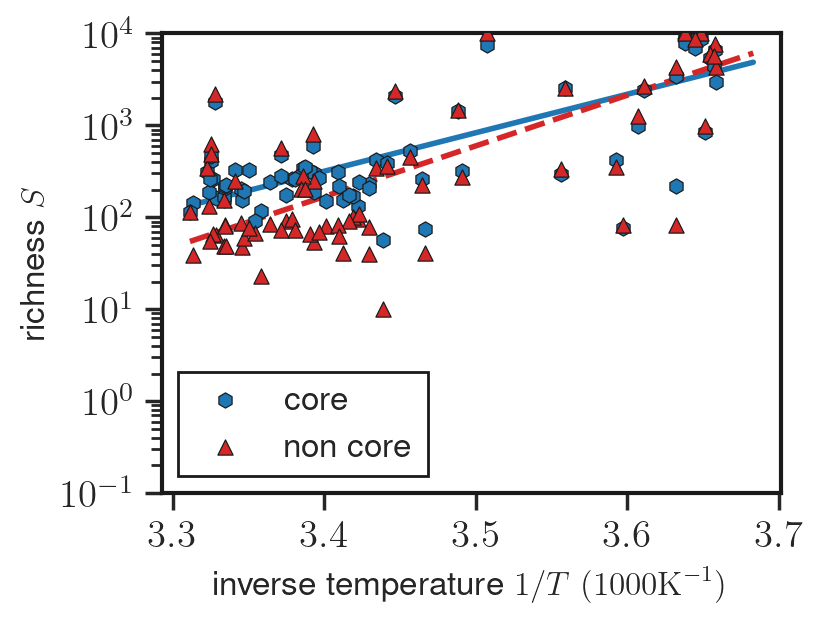

In [ ]:
figsize = (4, 3)
labelsize = 12

core_color = '#1f77b4'
noncore_color = '#d62728'
meta_marker = {'metaG': 'o', 'metaT': '^'}

fig, ax = plt.subplots(figsize=figsize, constrained_layout=True)

epsilon = {}
sigma_epsilon = {}

for group, color, marker, ls in [
    ('core', core_color, 'h', '-'),
    ('non_core', noncore_color, '^', '--')
]:
    d = df_core_data[df_core_data.group == group]

    dG = d[d.data == 'metaG'][['station', 'S_10', 'inverseTemperature']]
    dT = d[d.data == 'metaT'][['station', 'S_10']]

    df_plot = dT.merge(dG, on='station', suffixes=('_T', '_G'))
    # eta['eta'] = 10**eta['logk_T'] / 10**eta['logk_G']
    
    label = f'{group}'.replace('_', ' ')

    sns.scatterplot(
        x='inverseTemperature', y='S_10_T',
        data=df_plot, ax=ax,
        s=30, edgecolor='k',
        color=color, marker=marker,
        alpha=1., zorder=4, label=label
    )
    
    x = df_plot['inverseTemperature']
    y = df_plot['S_10_T']
    mask = y > 0
    m, q, *_ = linregress(x[mask], np.log(y[mask]))
    xf = np.linspace(x.min(), x.max(), 100)
    ax.plot(xf, np.exp(m*xf + q), color=color, lw=2, ls=ls)
    
    slope, intercept, r_value, p_value, std_err = linregress(x[mask], np.log(y[mask]))
    K_boltzmann = 8.617333262145e-5 # in eV/K
    E = slope * K_boltzmann * 1e3
    sigma_E = std_err * K_boltzmann * 1e3   
    print(f"{group} Temperature sensitivity of S  (BIC par): {E:1.2f}±{sigma_E:1.2f} eV. p-value={p_value:1.4f}")
    
 
    
    
    if meta == 'metaT':
        epsilon[group] = E
        sigma_epsilon[group] = sigma_E
    
ax.set_ylim(1e-1, 1e4)
ax.set_yscale('log')
ax.set_xlabel(r'inverse temperature $1/T\ (1000 \textrm{K}^{-1})$', fontsize=labelsize)
ax.set_ylabel(r'richness $S$', fontsize=labelsize)

core Temperature sensitivity of transcription efficiency (BIC par): 0.32±0.16 eV. p-value=0.0558
non_core Temperature sensitivity of transcription efficiency (BIC par): 0.18±0.24 eV. p-value=0.4705
core fitted Heaps law exponent (metaT): 0.69±0.03. p-value=0.0000
non_core fitted Heaps law exponent (metaT): 0.76±0.03. p-value=0.0000


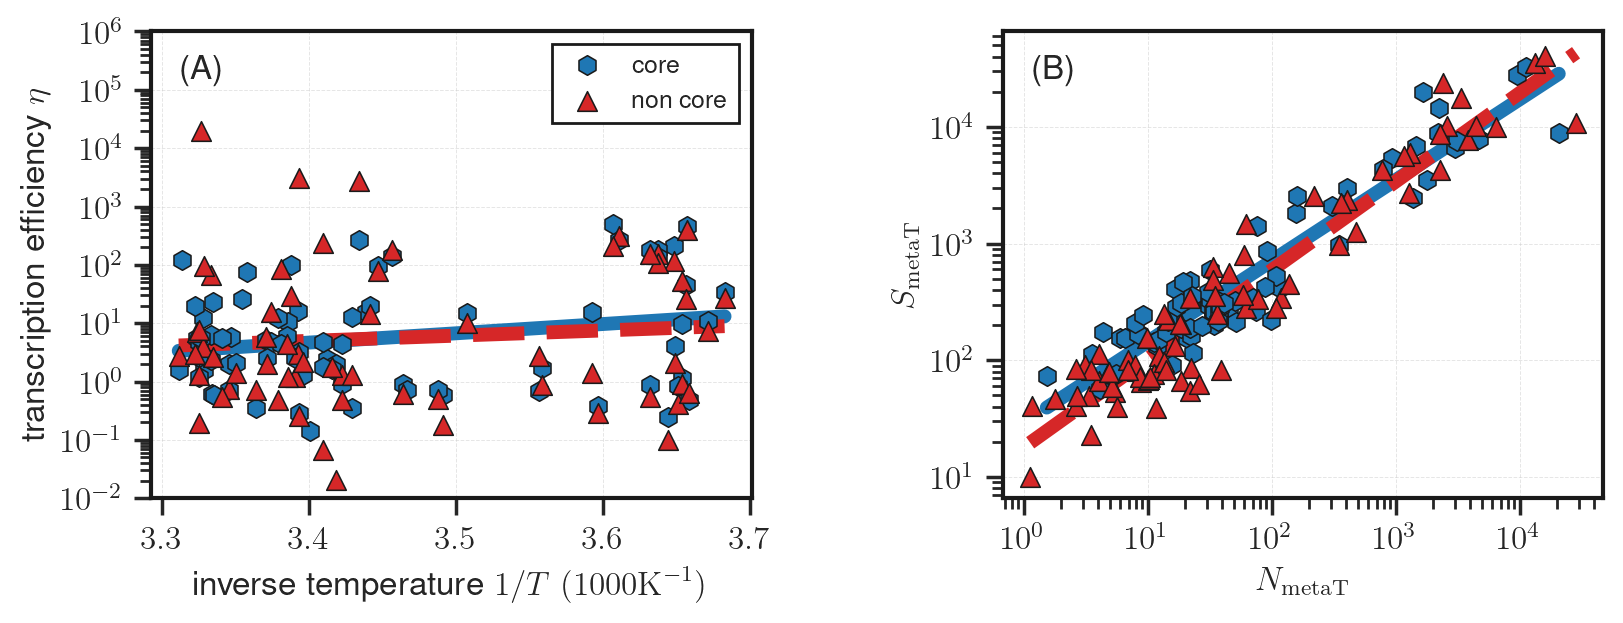

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import ScalarFormatter
from scipy.stats import linregress

# =========================
# STILE (coerente con SM)
# =========================
figsize = (8, 3)
labelsize = 12

core_color = '#1f77b4'
noncore_color = '#d62728'
meta_marker = {'metaG': 'o', 'metaT': '^'}

# =========================
# FIGURA 4 PANNELLI
# =========================
fig, axes = plt.subplots(
    1,2,
    figsize=figsize,
    constrained_layout=True,
    gridspec_kw={'wspace': 0.15, 'hspace': 0.2}
)

# # ==================================================
# # (A) alpha core vs non-core
# # ==================================================
# ax = axes[0, 0]
# ax.grid(True, lw=0.35, ls='--', alpha=0.5)
# ax.tick_params(labelsize=labelsize)

# for meta in ['metaG', 'metaT']:
#     d_core = df_core_data[
#         (df_core_data.data == meta) &
#         (df_core_data.group == 'core')
#     ]
#     d_noncore = df_core_data[
#         (df_core_data.data == meta) &
#         (df_core_data.group == 'non_core')
#     ]

#     d = d_core.merge(
#         d_noncore[['station', 'alpha']],
#         on='station',
#         suffixes=('_core', '_noncore')
#     )

#     ax.scatter(
#         d['alpha_core'], d['alpha_noncore'],
#         s=30, edgecolor='k',
#         marker=meta_marker[meta],
#         color=metacolor[meta],
#         zorder=5
#     )

# # ax.plot([-3, 0], [-3, 0], 'k--', lw=1, alpha=0.5)
# ax.set_xlim(0.5, 3.5)
# ax.set_ylim(0.5, 3.5)
# ax.set_xlabel(r'$\alpha_{\mathrm{core}}$', fontsize=labelsize)
# ax.set_ylabel(r'$\alpha_{\mathrm{non\text{-}core}}$', fontsize=labelsize)
# ax.text(0.05, 0.95, '(A)', transform=ax.transAxes,
#         ha='left', va='top', fontsize=12)

# # ==================================================
# # (B) k core vs non-core
# # ==================================================
# ax = axes[0, 1]
# ax.grid(True, lw=0.35, ls='--', alpha=0.5)
# ax.tick_params(labelsize=labelsize)

# for meta in ['metaG', 'metaT']:
#     d_core = df_core_data[
#         (df_core_data.data == meta) &
#         (df_core_data.group == 'core')
#     ]
#     d_noncore = df_core_data[
#         (df_core_data.data == meta) &
#         (df_core_data.group == 'non_core')
#     ]

#     d = d_core.merge(
#         d_noncore[['station', 'logk']],
#         on='station',
#         suffixes=('_core', '_noncore')
#     )

#     ax.scatter(
#         10**d['logk_core'], 10**d['logk_noncore'],
#         s=30, edgecolor='k',
#         marker=meta_marker[meta],
#         color=metacolor[meta],
#         zorder=5
#     )

# # ax.plot([1e-6, 1e2], [1e-6, 1e2], 'k--', lw=1, alpha=0.5)
# ax.set_xscale('log')
# ax.set_yscale('log')
# ax.set_xlabel(r'$k_{\mathrm{core}}$', fontsize=labelsize)
# ax.set_ylabel(r'$k_{\mathrm{non\text{-}core}}$', fontsize=labelsize)
# ax.text(0.05, 0.95, '(B)', transform=ax.transAxes,
#         ha='left', va='top', fontsize=12)

# ==================================================
# (C) eta vs inverse temperature
# ==================================================
ax = axes[0]
ax.grid(True, lw=0.35, ls='--', alpha=0.5)
ax.tick_params(labelsize=labelsize)

energy_dict = {}
std_energy_dict = {}
meta = 'metaT'

for group, color, marker, ls in [
    ('core', core_color, 'h', '-'),
    ('non_core', noncore_color, '^', '--')
]:
    d = df_core_data[df_core_data.group == group]

    dG = d[d.data == 'metaG'][['station', 'k_model', 'inverseTemperature']]
    dT = d[d.data == 'metaT'][['station', 'k_model']]

    eta = dT.merge(dG, on='station', suffixes=('_T', '_G'))
    # eta['eta'] = 10**eta['logk_T'] / 10**eta['logk_G']
    eta['eta'] = eta['k_model_T'] / eta['k_model_G']
    
    label = f'{group}'.replace('_', ' ')

    sns.scatterplot(
        x='inverseTemperature', y='eta',
        data=eta, ax=ax,
        s=50, edgecolor='k',
        color=color, marker=marker,
        alpha=1., zorder=4, label=label
    )

    x = eta['inverseTemperature']
    y = eta['eta']
    mask = y > 0
    m, q, *_ = linregress(x[mask], np.log(y[mask]))
    xf = np.linspace(x.min(), x.max(), 100)
    ax.plot(xf, np.exp(m*xf + q), color=color, lw=5, ls=ls)
    
    slope, intercept, r_value, p_value, std_err = linregress(x[mask], np.log(y[mask]))
    K_boltzmann = 8.617333262145e-5 # in eV/K
    E = slope * K_boltzmann * 1e3
    sigma_E = std_err * K_boltzmann * 1e3   
    print(f"{group} Temperature sensitivity of transcription efficiency (BIC par): {E:1.2f}±{sigma_E:1.2f} eV. p-value={p_value:1.4f}")
    
    if meta == 'metaT':
        energy_dict[group] = E
        std_energy_dict[group] = sigma_E
    
ax.set_ylim(1e-2, 1e6)
ax.set_yscale('log')
ax.set_xlabel(r'inverse temperature $1/T\ (1000 \textrm{K}^{-1})$', fontsize=labelsize)
ax.set_ylabel(r'transcription efficiency $\eta$', fontsize=labelsize)
ax.text(0.05, 0.95, '(A)', transform=ax.transAxes,
        ha='left', va='top', fontsize=12)
ax.legend(fontsize=9)

# ==================================================
# (D) Heaps law (metaT)
# ==================================================
ax = axes[1]
ax.grid(True, lw=0.35, ls='--', alpha=0.5)
ax.tick_params(labelsize=labelsize)

for group, color, marker, ls in [
    ('core', core_color, 'h', '-'),
    ('non_core', noncore_color, '^', '--')
]:
    d = df_core_data[
        (df_core_data.data == 'metaT') &
        (df_core_data.group == group)
    ]

    sns.scatterplot(
        x='N_10', y='S_10',
        data=d, ax=ax,
        s=50, edgecolor='k',
        color=color, marker=marker,
        zorder=4
    )
    
    # linear fit in log-log
    x = d['N_10']
    y = d['S_10']
    mask = (x > 0) & (y > 0)
    m, q, *_ = linregress(np.log(x[mask]), np.log(y[mask]))
    xf = np.linspace(x.min(), x.max(), 100)
    ax.plot(xf, np.exp(q)*xf**m, color=color, lw=5, ls=ls)
    # print(f'Heaps law exponent for {group}: {m:1.2f} ± {std_err:1.2f}')
    
    x_fit = np.log(x[mask])
    y_fit = np.log(y[mask])
    slope, intercept, r_value, p_value, std_err = linregress(x_fit, y_fit)
    print(f"{group} fitted Heaps law exponent (metaT): {slope:1.2f}±{std_err:1.2f}. p-value={p_value:1.4f}")

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel(r'$N_{\mathrm{metaT}}$', fontsize=labelsize)
ax.set_ylabel(r'$S_{\mathrm{metaT}}$', fontsize=labelsize)
ax.text(0.05, 0.95, '(B)', transform=ax.transAxes,
        ha='left', va='top', fontsize=12)

# =========================
# SALVATAGGIO
# =========================
# figname = f'../figures/SM/core_vs_noncore_scalings_{DATA_NORMALIZATION}Counts.png'
# os.makedirs(os.path.dirname(figname), exist_ok=True)
# plt.savefig(figname, dpi=300, bbox_inches='tight')
# print(f"Figure saved as {figname}")
figname = f"../figures/{DATA_NORMALIZATION}/SM/core_vs_noncore_scalings_{DATA_NORMALIZATION}Counts"
os.makedirs(os.path.dirname(figname), exist_ok=True)
for fmt in [".pdf", ".png"]:
    plt.savefig(f"{figname}{fmt}", dpi=300, bbox_inches="tight", transparent=True)

In [ ]:
energy_dict

{'core': np.float64(0.31569342585707405),
 'non_core': np.float64(0.1768876506970804)}

In [ ]:
for core in energy_dict.keys():
    E = energy_dict[core]
    sigma_E = std_energy_dict[core]
    print(f"{core} Temperature sensitivity of transcription efficiency (BIC par): {E:1.2f}±{sigma_E:1.2f} eV.")
    
    heaps_exponent = 1./(1.+E/epsilon[core])
    print(f"{core} Heaps law exponent predicted from energy sensitivities: {heaps_exponent:1.2f}")
    
    xi, xi_error = return_xi_and_error(E, sigma_E, epsilon[core], sigma_epsilon[core])
    print(f"{core} xi predicted from energy sensitivities: {xi:1.2f} ± {xi_error:1.2f}")

core Temperature sensitivity of transcription efficiency (BIC par): 0.32±0.16 eV.
core Heaps law exponent predicted from energy sensitivities: 0.72
core xi predicted from energy sensitivities: 0.72 ± 0.10
non_core Temperature sensitivity of transcription efficiency (BIC par): 0.18±0.24 eV.
non_core Heaps law exponent predicted from energy sensitivities: 0.86
non_core xi predicted from energy sensitivities: 0.86 ± 0.17


## 4. Sectors

In [ ]:
DATA_NORMALIZATION = "norm"  # either "norm" or "raw"

In [ ]:
filename = f"parameters_goodfit_{DATA_NORMALIZATION}_sector_SRF_micro_bacilla.csv"

sector_data = pd.read_csv(
    f"../fit/{filename}",
    index_col=["data", "sector"]
)

df_sector_data = sector_data.reset_index()

df_sector_data = df_sector_data.merge(
    gdf.reset_index()[['station', 'inverseTemperature']],
    on='station',
    how='left'
)
# rename "subset" with "group" in the column name
# df_sector_data = df_sector_data.rename(columns={'sector': 'group'})

display(df_sector_data.head())
sector_data.head()

,data,sector,station,N_10,S_10,nmin,zeta,zeta_low,zeta_high,alpha,...,logk_high,logN_mean,logN_low,logN_high,KS,p_KS,CvM,p_CvM,rejected,inverseTemperature
0,metaG,Q,7,1.845418,61,0.000538,0.739053,0.474352,1.183155,75.091349,...,0.597024,0.262505,0.134561,0.378960,0.086830,0.17825,0.063347,0.313,0.0,3.422470
1,metaG,Q,11,0.006275,2,0.002691,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.438678
2,metaG,Q,18,0.705763,26,0.001529,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.412548
3,metaG,Q,22,3.675375,107,0.000927,0.806600,0.439843,1.522574,3.105459,...,1.024334,0.563132,0.453063,0.681970,0.045304,0.62500,0.043122,0.410,0.0,3.418736
4,metaG,Q,23,1.400072,67,0.001262,0.885442,0.497064,1.449388,356.136920,...,0.996040,0.143112,0.037739,0.242754,0.065685,0.49150,0.045831,0.537,0.0,3.429666


station      N_10  S_10      nmin      zeta  zeta_low  \
data  sector                                                          
metaG Q             7  1.845418    61  0.000538  0.739053  0.474352   
      Q            11  0.006275     2  0.002691       NaN       NaN   
      Q            18  0.705763    26  0.001529       NaN       NaN   
      Q            22  3.675375   107  0.000927  0.806600  0.439843   
      Q            23  1.400072    67  0.001262  0.885442  0.497064   

              zeta_high       alpha   alpha_low  alpha_high  ...  logk_low  \
data  sector                                                 ...             
metaG Q        1.183155   75.091349   46.383607  125.078837  ...  0.315303   
      Q             NaN         NaN         NaN         NaN  ...       NaN   
      Q             NaN         NaN         NaN         NaN  ...       NaN   
      Q        1.522574    3.105459    0.839491  184.805598  ... -1.625289   
      Q        1.449388  356.136920  199.485710  583.600708  ...  0.751629   

              logk_high  logN_mean  logN_low  logN_high        KS     p_KS  \
data  sector                                                                 
metaG Q        0.597024   0.262505  0.134561   0.378960  0.086830  0.17825   
      Q             NaN        NaN       NaN        NaN       NaN      NaN   
      Q             NaN        NaN       NaN        NaN       NaN      NaN   
      Q        1.024334   0.563132  0.453063   0.681970  0.045304  0.62500   
      Q        0.996040   0.143112  0.037739   0.242754  0.065685  0.49150   

                   CvM  p_CvM  rejected  
data  sector                             
metaG Q       0.063347  0.313       0.0  
      Q            NaN    NaN       NaN  
      Q            NaN    NaN       NaN  
      Q       0.043122  0.410       0.0  
      Q       0.045831  0.537       0.0  

[5 rows x 21 columns]

In [ ]:
# # sector_data = pd.read_csv('../fit/parameters_fit_sector_micro_SRF_bacilla.csv', index_col=[0,1])
# sector_data = pd.read_csv(f'../fit/parameters_fit_{DATA_NORMALIZATION}Counts_sector_micro_SRF_bacilla.csv', index_col=[0,1])
# df_sector_data = sector_data.reset_index()

# # merge con gdf per temperatura
# df_sector_data = df_sector_data.merge(
#     gdf.reset_index()[['station', 'inverseTemperature']],
#     on='station',
#     how='left'
# )

# sector_data.head()

Sector Q - Sensibilità Temp (E): 0.13±0.35 eV. p=0.7146
Sector R - Sensibilità Temp (E): 0.91±0.28 eV. p=0.0016
Sector Q - Heaps exponent: 0.70±0.03. p=0.0000
Sector R - Heaps exponent: 0.63±0.04. p=0.0000


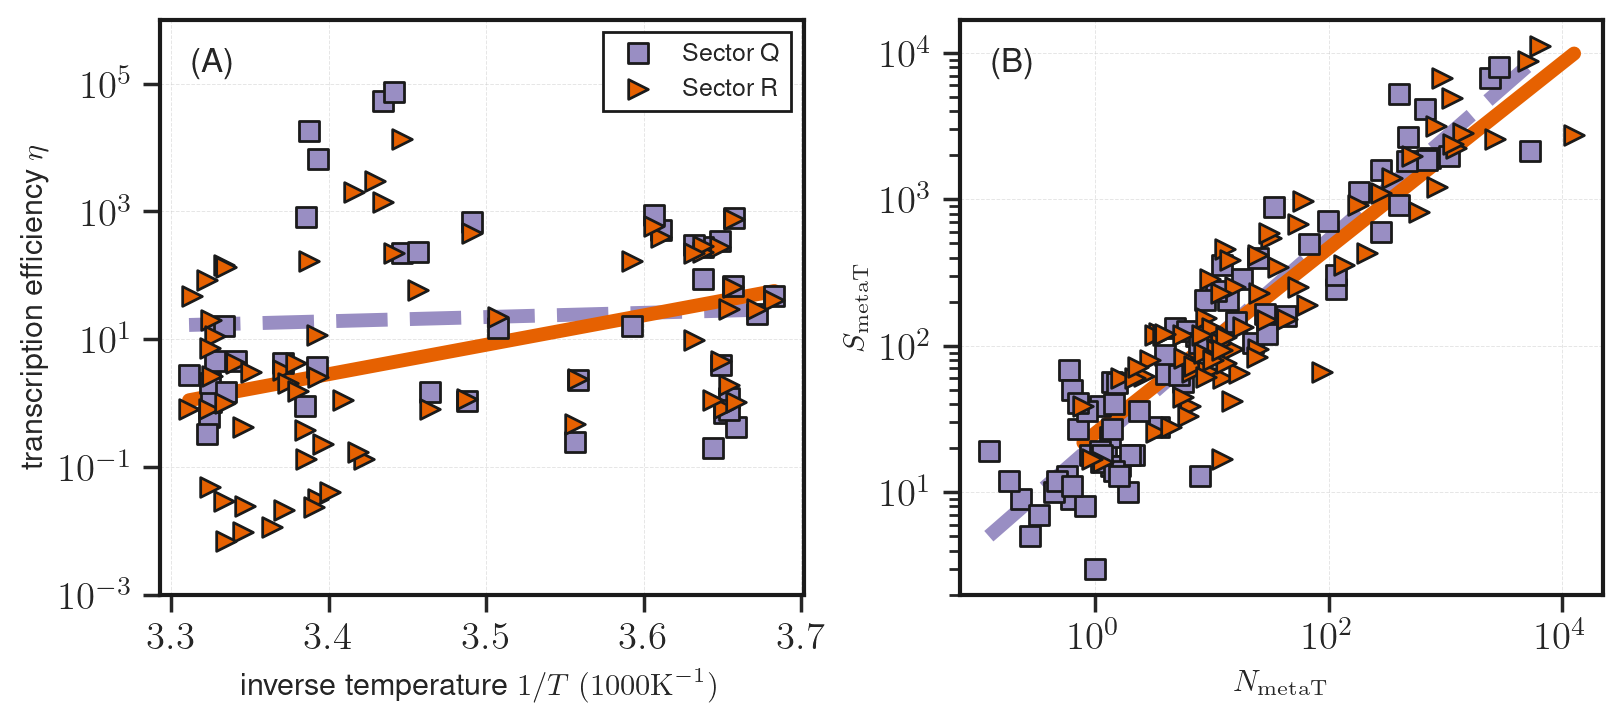

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from scipy.stats import linregress

# =========================
# CONFIGURAZIONE E COLORI
# =========================
figsize = (8, 3.5)
labelsize = 11

# Associamo Sector Q e Sector R ai colori usati in precedenza
sector_colors = {'Q': '#1f77b4', 'R': '#d62728'}
sector_colors = {
    'Q': '#31688e',  # viridis blue
    'R': '#35b779'   # viridis green
}
sector_colors = {
    'Q': "#998ec3",  # viridis dark purple
    'R': "#e66101"   # viridis yellow
}
sector_markers = {'Q': 'h', 'R': '^'}
sector_markers = {
    'Q': 's',   # square
    'R': '>'    # triangle up
}
sector_ls = {'Q': '--', 'R': '-'}

energy_dict_sectors = {}
std_energy_dict_sectors = {}
epsilon = {}
sigma_epsilon = {}

for sec in ['Q', 'R']:
    d = df_sector_data[df_sector_data.sector == sec]

    dG = d[d.data == 'metaG'][['station', 'S_10', 'inverseTemperature']]
    dT = d[d.data == 'metaT'][['station', 'S_10']]

    df_plot = dT.merge(dG, on='station', suffixes=('_T', '_G'))
    
    x = df_plot['inverseTemperature']
    y = df_plot['S_10_T']
    mask = y > 0
    m, q, *_ = linregress(x[mask], np.log(y[mask]))
    xf = np.linspace(x.min(), x.max(), 100)
    
    slope, intercept, r_value, p_value, std_err = linregress(x[mask], np.log(y[mask]))
    K_boltzmann = 8.617333262145e-5 # in eV/K
    E = slope * K_boltzmann * 1e3
    sigma_E = std_err * K_boltzmann * 1e3   

    epsilon[sec] = E
    sigma_epsilon[sec] = sigma_E

# =========================
# PREPARAZIONE DATI
# =========================
# (Assumo che df_sector_data sia già stato caricato e mergiato come indicato nel tuo snippet)

# Filtriamo solo i settori di interesse
df_sector_filtered = df_sector_data[df_sector_data['S_10'] > 5].copy()
df_filtered = df_sector_data[df_sector_data['sector'].isin(['Q', 'R'])].copy()

# Calcoliamo k dalla logk (se logk è in base 10)
# df_filtered['k_val'] = np.max(10**df_filtered['logk']-df_filtered['mu'], df_filtered['mu'], axis=1)
df_filtered['k_val'] = 10**df_filtered['logk']

# =========================
# FIGURA 2 PANNELLI
# =========================
fig, axes = plt.subplots(1, 2, figsize=figsize, constrained_layout=True)

# --------------------------------------------------
# (A) Efficienza di trascrizione eta vs 1/T
# --------------------------------------------------
ax = axes[0]
ax.grid(True, lw=0.35, ls='--', alpha=0.5)
ax.set_ylim(1e-3, 1e6)

for sec in ['Q', 'R']:
    d = df_filtered[df_filtered.sector == sec]
    
    # Separiamo metaG e metaT per calcolare il rapporto eta
    dG = d[d.data == 'metaG'][['station', 'k_val', 'inverseTemperature']]
    dT = d[d.data == 'metaT'][['station', 'k_val']]
    
    # Merge sulle station per avere metaG e metaT nella stessa riga
    eta_df = dT.merge(dG, on='station', suffixes=('_T', '_G'))
    eta_df['eta'] = eta_df['k_val_T'] / eta_df['k_val_G']
    
    # print(eta_df.head())
    
    # Scatter plot
    ax.scatter(
        eta_df['inverseTemperature'], eta_df['eta'],
        s=50, edgecolor='k', alpha=1.,
        color=sector_colors[sec], marker=sector_markers[sec],
        label=f'Sector {sec}', zorder=4
    )
    
    # Fit lineare in scala semi-log (Arrhenius)
    x = eta_df['inverseTemperature']
    y = eta_df['eta']
    mask = (y > 0) & (~np.isnan(y)) & (~np.isnan(x))
    
    if mask.sum() > 1:
        slope, intercept, r_val, p_val, std_err = linregress(x[mask], np.log(y[mask]))
        xf = np.linspace(x.min(), x.max(), 100)
        ax.plot(xf, np.exp(slope*xf + intercept), color=sector_colors[sec], lw=5, ls=sector_ls[sec])
        
        # Calcolo Energia di Attivazione apparente (eV)
        K_boltzmann = 8.617e-5 
        E = slope * K_boltzmann * 1e3 # Se inverseTemperature è in 1000/K
        print(f"Sector {sec} - Sensibilità Temp (E): {E:1.2f}±{std_err*K_boltzmann*1e3:1.2f} eV. p={p_val:1.4f}")
        energy_dict_sectors[sec] = E
        std_energy_dict_sectors[sec] = std_err*K_boltzmann*1e3

ax.set_yscale('log')
ax.set_xlabel(r'inverse temperature $1/T\ (1000 \textrm{K}^{-1})$', fontsize=labelsize)
ax.set_ylabel(r'transcription efficiency $\eta$', fontsize=labelsize)
# ax.set_title('(A) Temperature Sensitivity', loc='left', fontsize=labelsize)
ax.text(0.05, 0.95, '(A)', transform=ax.transAxes,
        ha='left', va='top', fontsize=12)
ax.legend(fontsize=9)

# --------------------------------------------------
# (B) Heaps law (metaT)
# --------------------------------------------------
ax = axes[1]
ax.grid(True, lw=0.35, ls='--', alpha=0.5)

for sec in ['Q', 'R']:
    d = df_filtered[(df_filtered.data == 'metaT') & (df_filtered.sector == sec)]
    
    # Scatter plot N vs S
    ax.scatter(
        d['N_10'], d['S_10'],
        s=50, edgecolor='k', alpha=1.,
        color=sector_colors[sec], marker=sector_markers[sec],
        zorder=4
    )
    
    # Fit Heaps (lineare in log-log)
    x = d['N_10']
    y = d['S_10']
    mask = (x > 0) & (y > 0)
    
    if mask.sum() > 1:
        m, q, r, p, err = linregress(np.log(x[mask]), np.log(y[mask]))
        xf = np.sort(x[mask])
        ax.plot(xf, np.exp(q) * xf**m, color=sector_colors[sec], lw=5, ls=sector_ls[sec])
        print(f"Sector {sec} - Heaps exponent: {m:1.2f}±{err:1.2f}. p={p:1.4f}")

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel(r'$N_{\mathrm{metaT}}$', fontsize=labelsize)
ax.set_ylabel(r'$S_{\mathrm{metaT}}$', fontsize=labelsize)
# ax.set_title('(B) Heaps Law (metaT)', loc='left', fontsize=labelsize)
ax.text(0.05, 0.95, '(B)', transform=ax.transAxes,
        ha='left', va='top', fontsize=12)

# figname = f'../figures/SM/sectors_scalings_{DATA_NORMALIZATION}Counts.png'
# os.makedirs(os.path.dirname(figname), exist_ok=True)
# plt.savefig(figname, dpi=300, bbox_inches='tight')
figname = f"../figures/{DATA_NORMALIZATION}/SM/sectors_scalings_{DATA_NORMALIZATION}Counts"
os.makedirs(os.path.dirname(figname), exist_ok=True)
for fmt in [".pdf", ".png"]:
    plt.savefig(f"{figname}{fmt}", dpi=300, bbox_inches="tight", transparent=True)
plt.show()

In [ ]:
for sector in energy_dict_sectors.keys():
    E = energy_dict_sectors[sector]
    sigma_E = std_energy_dict_sectors[sector]
    print(f"{sector} Temperature sensitivity of transcription efficiency (BIC par): {E:1.2f}±{sigma_E:1.2f} eV.")
    
    heaps_exponent = 1./(1.+E/epsilon[sector])
    print(f"{sector} Heaps law exponent predicted from energy sensitivities: {heaps_exponent:1.2f}")
    
    xi, xi_error = return_xi_and_error(E, sigma_E, epsilon[sector], sigma_epsilon[sector])
    print(f"{sector} xi predicted from energy sensitivities: {xi:1.2f} ± {xi_error:1.2f}")

Q Temperature sensitivity of transcription efficiency (BIC par): 0.13±0.35 eV.
Q Heaps law exponent predicted from energy sensitivities: 0.89
Q xi predicted from energy sensitivities: 0.89 ± 0.27
R Temperature sensitivity of transcription efficiency (BIC par): 0.91±0.28 eV.
R Heaps law exponent predicted from energy sensitivities: 0.45
R xi predicted from energy sensitivities: 0.45 ± 0.08


## Occupancy

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(8,3), constrained_layout=True, gridspec_kw={'hspace': 0.5}, sharey=True)
labelsize=12

for meta, ax in zip(['metaG', 'metaT'], axes.flatten()):
    # set font size of the axes to 12
    ax.tick_params(axis='both', which='major', labelsize=labelsize)
    # ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel('occupancy', fontsize=labelsize)
    if meta == 'metaG':
        ax.set_ylabel('PDF', fontsize=labelsize)
        text = '(A)'
        ax.text(0.95, 0.95, text, transform=ax.transAxes, ha='right', va='top', fontsize=12)
    else:
        text = '(B)'
        ax.text(0.95, 0.95, text, transform=ax.transAxes, ha='right', va='top', fontsize=12)
    ax.grid(True, lw=0.35, ls='--', alpha=0.5)
    
    data = df_meta[meta].fillna(0).astype(bool).sum(axis=1)/len(df_meta[meta].columns)  # occupancy
    bins = np.linspace(0, 1, 21)
    hist, bin_edges = np.histogram(data, bins=bins, density=True)
    sns.lineplot(x=bin_edges[:-1], y=hist, ax=ax, color=metacolor[meta], lw=3.3, marker=metamarker[meta], markersize=6, markeredgecolor='k')
    
    # find the threshold such that 50% of the data is below it
    quantile = 0.9
    threshold = data.quantile(quantile)
    ax.axvline(threshold, color=metacolor[meta], lw=2.5, ls='--')
    text = r'$\theta_{.9}=$' + f'{threshold:1.2f}'
    ax.text(threshold+0.02, ax.get_ylim()[0]*1.5, text, color=metacolor[meta], fontsize=11)

: 

In [ ]:

valid_genes = df_meta[meta].sum(axis=1)
valid_genes = valid_genes[valid_genes > 0].index

geneID_sorted_by_occupancy = (
    df_meta[meta].loc[valid_genes]
    .astype(bool)
    .sum(axis=1)
    .sort_values()
    .index
)

percentile = 90
n_genes = len(geneID_sorted_by_occupancy)
# Calcola la dimensione del gruppo "Top" (ad esempio, 10% del totale)
n_top = int(n_genes * (100 - percentile) / 100) 
print(f'Number of genes in the top {100 - percentile}%: {n_top}')

# 1. Geni "TOP" (i PIÙ occupati)
# Prendi gli ultimi n_top geni dall'array ordinato (che va dal meno al più occupato)
top_genes = geneID_sorted_by_occupancy[-n_top:] 

# 2. Geni "REMAINING" (Il restante 90%)
# Prendi tutti i geni che NON sono in top_genes (i primi n_genes - n_top)
remaining_genes = geneID_sorted_by_occupancy[:-n_top] # Tutti tranne gli ultimi n_top

print(f'Total genes: {n_genes}. Top genes: {len(top_genes)}. Remaining genes: {len(remaining_genes)}')

# --- Calcoli con i gruppi corretti ---

total_abundance_top_genes = df_meta[meta].loc[top_genes].sum().sum()
total_abundance_remaining_genes = df_meta[meta].loc[remaining_genes].sum().sum()

print(f'Total abundance of top {100 - percentile}% genes: {total_abundance_top_genes:1.2e}')
print(f'Total abundance of remaining genes: {total_abundance_remaining_genes:1.2e}')
print('Total abundance:', total_abundance_top_genes + total_abundance_remaining_genes)

# Questo CHECK dovrebbe essere vicino a 0 (a parte per eventuali floating point errors)
print('Total abundance check:', df_meta[meta].loc[valid_genes].sum().sum() - (total_abundance_top_genes + total_abundance_remaining_genes))

: 

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(8,3), constrained_layout=True, gridspec_kw={'hspace': 0.5}, sharey=True)
labelsize=12

for meta, ax in zip(['metaG', 'metaT'], axes.flatten()):
        
    valid_genes = df_meta[meta].sum(axis=1)
    valid_genes = valid_genes[valid_genes > 0].index

    geneID_sorted_by_occupancy = (
        df_meta[meta].loc[valid_genes]
        .astype(bool)
        .sum(axis=1)
        .sort_values()
        .index
    )

    percentile = 90
    n_genes = len(geneID_sorted_by_occupancy)
    # Calcola la dimensione del gruppo "Top" (ad esempio, 10% del totale)
    n_top = int(n_genes * (100 - percentile) / 100) 
    print(f'Number of genes in the top {100 - percentile}%: {n_top}')

    # 1. Geni "TOP" (i PIÙ occupati)
    # Prendi gli ultimi n_top geni dall'array ordinato (che va dal meno al più occupato)
    top_genes = geneID_sorted_by_occupancy[-n_top:] 

    # 2. Geni "REMAINING" (Il restante 90%)
    # Prendi tutti i geni che NON sono in top_genes (i primi n_genes - n_top)
    remaining_genes = geneID_sorted_by_occupancy[:-n_top] # Tutti tranne gli ultimi n_top

    print(f'Total genes: {n_genes}. Top genes: {len(top_genes)}. Remaining genes: {len(remaining_genes)}')

    # --- Calcoli con i gruppi corretti ---

    total_abundance_top_genes = df_meta[meta].loc[top_genes].sum().sum()
    total_abundance_remaining_genes = df_meta[meta].loc[remaining_genes].sum().sum()

    print(f'Total abundance of top {100 - percentile}% genes: {total_abundance_top_genes:1.2e}')
    print(f'Total abundance of remaining genes: {total_abundance_remaining_genes:1.2e}')
    print('Total abundance:', total_abundance_top_genes + total_abundance_remaining_genes)

    # Questo CHECK dovrebbe essere vicino a 0 (a parte per eventuali floating point errors)
    print('Total abundance check:', df_meta[meta].loc[valid_genes].sum().sum() - (total_abundance_top_genes + total_abundance_remaining_genes))
    
    percentiles = [1, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
    # percentiles = [0.01, 0.02, 0.05, 0.1, 0.2, 0.5, 1, 2, 5, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
    top_abundances = []
    remaining_abundances = []
    for perc in percentiles:
        n_top = int(n_genes * perc / 100)
        top_genes = geneID_sorted_by_occupancy[-n_top:]
        remaining_genes = geneID_sorted_by_occupancy[:-n_top]
        total_abundance_top_genes = df_meta[meta].loc[top_genes].sum().sum()
        total_abundance_remaining_genes = df_meta[meta].loc[remaining_genes].sum().sum()
        top_abundances.append(total_abundance_top_genes)
        remaining_abundances.append(total_abundance_remaining_genes)
        
    ax.scatter(percentiles, top_abundances, color=metacolor[meta], edgecolor='k', s=50, marker='o', label='Top genes')
    # ax.scatter(percentiles, remaining_abundances, color=metacolor[meta], edgecolor='k', s=50, marker='s', label='Remaining genes')
    ax.set_xlabel('Percentile of most present genes')
    ax.set_ylabel('Total abundance')
    ax.set_yscale('log')
    # ax.set_xscale('log')
    ax.grid(True, which='major', linestyle='--', lw=0.5)
    ax.legend()

: 

: 

# 0. Convolution with lognormal

In [ ]:
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt

# --- 1. Parameters ---
np.random.seed(42)
n_samples = 200000 
alpha = 2.0          # Shape parameter
scale = 10.0         # Scale parameter
mu_min = 5.0         # Shift / Minimum value

# --- 2. Generate Data ---
# A) The True PDF (Continuous): Lambda ~ Shifted Lomax
lambdas = stats.lomax.rvs(c=alpha, scale=scale, loc=mu_min, size=n_samples)

# B) The Convolved Distribution (Discrete): Counts ~ Poisson(Lambda)
counts = stats.poisson.rvs(mu=lambdas)

# --- 3. Logarithmic Binning Helper Function ---
def get_log_binned_pdf(data, num_bins=60):
    """
    Computes log-binned probability density for a given dataset.
    """
    # Filter strictly positive values for logspace
    data = data[data > 0]
    
    # Define logarithmic bins
    min_val = np.min(data)
    max_val = np.max(data)
    # Ensure min_val is at least slightly above 0 for log10
    if min_val < 1: min_val = 1
        
    bins = np.logspace(np.log10(min_val), np.log10(max_val), num_bins)
    
    # Compute histogram
    hist_counts, bin_edges = np.histogram(data, bins=bins, density=False)
    
    # Compute centers and widths
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    bin_widths = np.diff(bin_edges)
    
    # Normalize to get PDF
    pdf_val = hist_counts / (len(data) * bin_widths)
    
    return bin_centers, pdf_val

# Get densities for both datasets
lambda_x, lambda_y = get_log_binned_pdf(lambdas)
counts_x, counts_y = get_log_binned_pdf(counts)

# --- 4. Plotting ---
plt.figure(figsize=(11, 7))

# Plot A: The Input (True PDF - Shifted Lomax)
plt.loglog(lambda_x, lambda_y, 'o', markersize=4, color='red', alpha=0.6, 
           label=r'Input: True PDF ($\lambda \sim$ Shifted Lomax)')

# Plot B: The Output (Convolved - Poisson Mixture)
plt.loglog(counts_x, counts_y, 's', markersize=4, color='blue', alpha=0.6, 
           label=r'Output: Poisson Counts ($k \sim$ Pois($\lambda$))')

# Plot C: Theoretical Shifted Lomax Curve (Ground Truth)
# x range for theory
x_theory = np.logspace(np.log10(mu_min), np.log10(max(lambda_x)), 200)
# PDF of Shifted Lomax: lomax.pdf(x - loc)
y_theory = stats.lomax.pdf(x_theory, c=alpha, scale=scale, loc=mu_min)
plt.loglog(x_theory, y_theory, 'k-', linewidth=1.5, alpha=0.8, 
           label='Theoretical Shifted Lomax PDF')

# Add vertical line for the hard cutoff mu
plt.axvline(x=mu_min, color='gray', linestyle='--', alpha=0.7, label=f'Cutoff $\mu={mu_min}$')

# Styling
plt.xlabel('Value (Rate $\lambda$ or Count $k$)', fontsize=12)
plt.ylabel('Probability Density', fontsize=12)
plt.title(f'Comparison: True PDF vs Poisson Convolved\nLog-Log Scale with Log Binning ($\\alpha={alpha}, \mu={mu_min}$)', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, which="both", ls="-", alpha=0.2)

plt.tight_layout()
plt.show()

: 

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import lomax, lognorm

# ==========================================
# 1. Configurazione e Parametri
# ==========================================
np.random.seed(42)

# Parametri Lomax (Veri)
# PDF: (alpha / k) * (1 + x/k)^(-1-alpha)
alpha_true = 3.0
k_true = 10.0 
n_genes = 20000 

# Parametri Log-Normale (Lunghezza Geni)
s_len = 0.6          # sigma (shape)
scale_len = np.exp(7.0) # media ~1100 bp

# ==========================================
# 2. Generazione Dati
# ==========================================

# A. Generiamo la vera abbondanza (True Distribution)
true_abundances = lomax.rvs(c=alpha_true, scale=k_true, size=n_genes)
# Rimuoviamo eventuali zero o valori troppo piccoli per evitare problemi col log
true_abundances = true_abundances[true_abundances > 1e-2]

# B. Generiamo le lunghezze dei geni
# Assumiamo indipendenza tra lunghezza e abbondanza iniziale
gene_lengths = lognorm.rvs(s=s_len, scale=scale_len, size=len(true_abundances))

# ==========================================
# 3. Processo di Sampling con Bias (Length Bias)
# ==========================================

# La probabilità di pescare un gene è proporzionale a Abbondanza * Lunghezza
weights = true_abundances * gene_lengths
probs = weights / weights.sum()

# Simuliamo il sequenziamento (resampling)
# Campioniamo N volte dalla popolazione originale usando i pesi distorti
depth = 200000
observed_data = np.random.choice(true_abundances, size=depth, p=probs)

# ==========================================
# 4. Fitting dei Modelli
# ==========================================

# Fit sulla distribuzione vera
params_true = lomax.fit(true_abundances, floc=0)
alpha_fit_t, _, k_fit_t = params_true

# Fit sulla distribuzione distorta (biased)
params_biased = lomax.fit(observed_data, floc=0)
alpha_fit_b, _, k_fit_b = params_biased

print(f"VERO (Input):      alpha={alpha_true}, k={k_true}")
print(f"FIT (True Data):   alpha={alpha_fit_t:.3f}, k={k_fit_t:.3f}")
print(f"FIT (Biased Data): alpha={alpha_fit_b:.3f}, k={k_fit_b:.3f}")

# ==========================================
# 5. Calcolo PDF empirica per plot Log-Log
# ==========================================

def get_log_binned_pdf(data, num_bins=50):
    """
    Calcola la PDF empirica usando bin spaziati logaritmicamente.
    Necessario per avere punti puliti su un grafico log-log.
    """
    min_val = np.min(data)
    max_val = np.max(data)
    
    # Creiamo bin spaziati esponenzialmente
    bins = np.logspace(np.log10(min_val), np.log10(max_val), num_bins)
    
    # Calcoliamo l'istogramma
    counts, edges = np.histogram(data, bins=bins)
    
    # Calcoliamo i centri dei bin (media geometrica per scala log)
    centers = np.sqrt(edges[:-1] * edges[1:])
    
    # Calcoliamo la larghezza dei bin
    widths = edges[1:] - edges[:-1]
    
    # Normalizziamo per ottenere la densità (PDF)
    # Density = Count / (Total_Count * Bin_Width)
    density = counts / (np.sum(counts) * widths)
    
    return centers, density

# Otteniamo i punti per il plot
x_true, y_true = get_log_binned_pdf(true_abundances)
x_biased, y_biased = get_log_binned_pdf(observed_data)

# ==========================================
# 6. Plotting Log-Log
# ==========================================
plt.figure(figsize=(10, 8))

# A. Plot dei Dati Empirici (Punti)
plt.loglog(x_true, y_true, 'o', color='blue', alpha=0.5, label='True Data (Empirical PDF)')
plt.loglog(x_biased, y_biased, 's', color='red', alpha=0.5, label='Biased Data (Empirical PDF)')

# B. Plot delle Curve Fittate (Linee)
x_space = np.logspace(np.log10(min(x_true)), np.log10(max(x_true)), 200)

# PDF Teorica del fit sui dati veri
pdf_true_fit = lomax.pdf(x_space, c=alpha_fit_t, scale=k_fit_t)
plt.loglog(x_space, pdf_true_fit, 'b-', linewidth=2, label=f'Lomax Fit True (a={alpha_fit_t:.2f})')

# PDF Teorica del fit sui dati distorti
pdf_biased_fit = lomax.pdf(x_space, c=alpha_fit_b, scale=k_fit_b)
plt.loglog(x_space, pdf_biased_fit, 'r--', linewidth=2, label=f'Lomax Fit Biased (a={alpha_fit_b:.2f})')

plt.title('Confronto True vs Biased Distribution (Log-Log Scale)')
plt.xlabel('Abbondanza (Log)')
plt.ylabel('Densità di Probabilità PDF (Log)')
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.4)

plt.show()

: 

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import lomax, lognorm, ks_1samp
from scipy.optimize import minimize
import sys

# ==========================================
# 0. Generazione Dati (Come prima)
# ==========================================
np.random.seed(42)

# Parametri Veri
alpha_true = 3.0
k_true = 10.0
n_genes = 10000

# 1. Genera Vera Abbondanza
true_abundances = lomax.rvs(c=alpha_true, scale=k_true, size=n_genes)
true_abundances = true_abundances[true_abundances > 0]

# 2. Genera Bias Lunghezza
s_len = 0.6
scale_len = np.exp(7.0)
gene_lengths = lognorm.rvs(s=s_len, scale=scale_len, size=len(true_abundances))

# 3. Sampling Biased (Sequenziamento)
weights = true_abundances * gene_lengths
probs = weights / weights.sum()
depth = 150000
# I dati osservati devono essere INTERI (natural numbers) per questo metodo
observed_data = np.random.choice(true_abundances, size=depth, p=probs)
observed_counts = np.round(observed_data).astype(int)
observed_counts = observed_counts[observed_counts > 0] # Z >= 1

print(f"Dati generati: {len(observed_counts)} osservazioni.")
print("Inizio procedura di fitting avanzata (Clauset method style)...")

# ==========================================
# 1. Definizioni Funzioni del Modello
# ==========================================

def lomax_ccdf(x, alpha, k):
    """Complementary CDF (Survival Function): P(X > x)"""
    # S(x) = (1 + x/k)^(-alpha)
    return (1.0 + x / k) ** (-alpha)

def lomax_pmf_discrete(z, alpha, k, mu_min):
    """
    Probabilità discreta P(Z=z) normalizzata per z >= mu_min.
    P(z) = S(z) - S(z+1)
    Normalization factor is S(mu_min) because sum_{z=mu}^\infty P(z) = S(mu)
    """
    prob_unnorm = lomax_ccdf(z, alpha, k) - lomax_ccdf(z + 1.0, alpha, k)
    norm_factor = lomax_ccdf(mu_min, alpha, k)
    return prob_unnorm / norm_factor

def lomax_cdf_discrete(z, alpha, k, mu_min):
    """
    CDF Discreta Condizionale: P(Z <= z | Z >= mu_min)
    CDF(z) = 1 - (S(z+1) / S(mu_min))
    """
    s_z_plus_1 = lomax_ccdf(z + 1.0, alpha, k)
    s_mu = lomax_ccdf(mu_min, alpha, k)
    return 1.0 - (s_z_plus_1 / s_mu)

# ==========================================
# 2. Funzioni di Fitting e Statistica
# ==========================================

def neg_log_likelihood(params, data, mu_min):
    """Funzione obiettivo da minimizzare (Negative Log Likelihood)"""
    alpha, k = params
    if alpha <= 0 or k <= 0: return np.inf
    
    # Calcolo probabilità per ogni punto dati
    # Usiamo la formulazione logaritmica per stabilità numerica sarebbe meglio,
    # ma per chiarezza usiamo la PMF diretta qui.
    probs = lomax_pmf_discrete(data, alpha, k, mu_min)
    
    # Evitiamo log(0)
    probs = np.maximum(probs, 1e-300)
    return -np.sum(np.log(probs))

def fit_lomax_to_subset(data, mu_min):
    """Fitta Alpha e K su un sottoinsieme di dati >= mu_min"""
    subset = data[data >= mu_min]
    if len(subset) < 10: return None, np.inf # Troppo pochi dati
    
    # Stima iniziale
    initial_guess = [3.0, 10.0]
    
    # Ottimizzazione
    res = minimize(neg_log_likelihood, initial_guess, args=(subset, mu_min),
                   method='Nelder-Mead', bounds=[(0.01, 100), (0.01, 1000)])
    
    if not res.success:
        return None, np.inf
    
    alpha_est, k_est = res.x
    
    # Calcolo KS Statistic
    # Confrontiamo la CDF teorica discreta con la CDF empirica
    # ks_1samp vuole una funzione che prenda 'x' e ritorni la CDF
    ks_stat, _ = ks_1samp(subset, lambda x: lomax_cdf_discrete(x, alpha_est, k_est, mu_min))
    
    return (alpha_est, k_est), ks_stat

# ==========================================
# 3. Trovare la soglia ottimale (mu_KS)
# ==========================================

print("Ricerca della soglia ottimale (mu_KS)...")

# Per velocità in questo script demo, non testiamo OGNI singolo intero se sono troppi,
# ma prendiamo i quantili o un set di valori unici.
unique_vals = np.unique(observed_counts)
unique_vals = np.sort(unique_vals)

# Limitiamo la ricerca per evitare tempi biblici nello script demo
# Testiamo fino all'80-esimo percentile
candidates = unique_vals[unique_vals < np.percentile(observed_counts, 80)]
# Decimiamo se sono troppi candidati (es. max 100 check)
if len(candidates) > 100:
    candidates = np.linspace(min(candidates), max(candidates), 100).astype(int)

best_ks = np.inf
best_mu = None
best_params = None

# Barra di avanzamento rudimentale
total_checks = len(candidates)
for i, mu in enumerate(candidates):
    params, ks = fit_lomax_to_subset(observed_counts, mu)
    
    if params is None: continue
    
    if ks < best_ks:
        best_ks = ks
        best_mu = mu
        best_params = params
        
    # Feedback ogni tanto
    if i % 20 == 0:
        sys.stdout.write(f"\rChecking mu={mu} (Progress: {i}/{total_checks}). Best KS: {best_ks:.4f}")
        sys.stdout.flush()

print(f"\n\n--- Trovato Ottimo ---")
print(f"Optimal Threshold (mu_KS): {best_mu}")
print(f"Best KS Statistic: {best_ks:.4f}")
print(f"Fitted Params at mu_KS: alpha={best_params[0]:.4f}, k={best_params[1]:.4f}")

# ==========================================
# 4. Bootstrapping per P-value
# ==========================================
# Filtriamo i dati finali
final_data = observed_counts[observed_counts >= best_mu]
n_final = len(final_data)

n_bootstraps = 100  # Usiamo 100 per velocità demo, metti 999 per produzione
print(f"\nStarting Bootstrap ({n_bootstraps} iterations)...")

ks_simulated = []
fit_alpha_est = best_params[0]
fit_k_est = best_params[1]

for b in range(n_bootstraps):
    # 1. Genera dataset sintetico dai parametri fittati
    # Generiamo usando la CDF inversa (metodo sampling) o rejection sampling
    # Qui usiamo un trick veloce: generiamo float continui e discretizziamo
    # Lomax continua -> floor -> check >= mu
    
    # Generiamo un eccesso per compensare il filtro mu
    sim_raw = lomax.rvs(c=fit_alpha_est, scale=fit_k_est, size=n_final*2)
    sim_discrete = np.floor(sim_raw).astype(int)
    sim_data = sim_discrete[sim_discrete >= best_mu]
    
    # Prendiamo esattamente n_final campioni
    if len(sim_data) >= n_final:
        sim_data = sim_data[:n_final]
    else:
        # Fallback raro se non ne abbiamo abbastanza
        continue

    # 2. Riffittiamo sui dati sintetici (fissati a mu_KS trovato prima)
    # Nota: Nella procedura completa di Clauset a volte si rifà la ricerca di mu, 
    # ma spesso si fissa mu per testare la bontà del fit parametrico.
    # Qui fittiamo alpha/k su sim_data assumendo mu fisso.
    res_boot = minimize(neg_log_likelihood, [fit_alpha_est, fit_k_est], 
                        args=(sim_data, best_mu), method='Nelder-Mead')
    
    if res_boot.success:
        alpha_b, k_b = res_boot.x
        # 3. Calcoliamo KS statistica sintetica
        ks_b, _ = ks_1samp(sim_data, lambda x: lomax_cdf_discrete(x, alpha_b, k_b, best_mu))
        ks_simulated.append(ks_b)
    
    if b % 10 == 0:
        sys.stdout.write(f"\rBootstrap: {b}/{n_bootstraps}")
        sys.stdout.flush()

ks_simulated = np.array(ks_simulated)

# Calcolo P-value
# P = (frazione di KS_sim >= KS_obs)
p_value_ks = np.sum(ks_simulated >= best_ks) / len(ks_simulated)
# Minimal p-value logic
p_value_ks = max(p_value_ks, 1.0/n_bootstraps)

print(f"\n\n--- Risultati Finali ---")
print(f"P-value (KS Test): {p_value_ks:.4f}")
print("Interpretazione: Se p-value > 0.05 (o 0.1), non possiamo rifiutare l'ipotesi")
print("che i dati seguano la distribuzione Lomax (per x >= mu_KS).")

# ==========================================
# 5. Visualizzazione
# ==========================================
plt.figure(figsize=(10, 6))

# A. Cumulative Complementare (CCDF) Empirical
# Ordina i dati
sorted_data = np.sort(final_data)
# Probabilità empirica P(X >= x)
y_vals = 1.0 - np.arange(len(sorted_data)) / len(sorted_data)

plt.loglog(sorted_data, y_vals, 'o', color='black', markersize=3, label='Empirical Data (x >= mu_KS)')

# B. Fit Teorico
x_space = np.logspace(np.log10(min(sorted_data)), np.log10(max(sorted_data)), 100)
# Calcoliamo la CCDF teorica condizionale: S(x)/S(mu)
y_theory = lomax_ccdf(x_space, fit_alpha_est, fit_k_est) / lomax_ccdf(best_mu, fit_alpha_est, fit_k_est)

plt.loglog(x_space, y_theory, 'r-', linewidth=2, label=f'Fitted Lomax Discrete\n(mu={best_mu}, a={fit_alpha_est:.2f}, k={fit_k_est:.2f})')

plt.xlabel('Abundance (x)')
plt.ylabel('CCDF P(X >= x)')
plt.title(f'Goodness of Fit (p-value={p_value_ks:.3f})')
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.4)
plt.show()

: 

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import lomax, lognorm, ks_1samp
from scipy.optimize import minimize
import sys

# ==========================================
# 1. Configurazione Parametri
# ==========================================
np.random.seed(42)

# --- Parametri della Generazione (Verità) ---
ALPHA_TRUE = 2.0       # Shape
K_TRUE = 10.0          # Scale
MU_GEN = 5.0           # Location (Spostamento minimo sull'asse x)
N_GENES = 15000        # Numero di geni totali

# --- Parametri Bias Lunghezza ---
S_LEN = 0.6            # Sigma della log-normale
SCALE_LEN = np.exp(7.0)# Media della lunghezza (~1100bp)

# --- Parametri Esperimento ---
SEQUENCING_DEPTH = 2000000  # Numero di reads totali
N_BOOTSTRAPS = 5          # Numero di bootstrap (metti 1000 per pubblicazione)

# ==========================================
# 2. Funzioni Matematiche del Modello
# ==========================================

def lomax_ccdf(x, alpha, k, mu_loc=0):
    """
    Survival Function (CCDF) teorica continua: P(X > x)
    S(x) = (1 + (x - mu)/k)^(-alpha)
    """
    # Assicuriamo che x sia almeno mu_loc per evitare numeri complessi o errati
    val = np.maximum(0.0, x - mu_loc)
    return (1.0 + val / k) ** (-alpha)

def lomax_pmf_discrete(z, alpha, k, mu_min):
    """
    Probabilità discreta P(Z=z) normalizzata per z >= mu_min.
    Modelliamo la probabilità discreta come l'area sotto la curva tra z e z+1
    P(z) = S(z) - S(z+1)
    """
    # La probabilità non normalizzata
    p_unnorm = lomax_ccdf(z, alpha, k, mu_loc=0) - lomax_ccdf(z + 1.0, alpha, k, mu_loc=0)
    
    # Fattore di normalizzazione: Somma di tutte le P(z) da mu_min a infinito
    # Che corrisponde esattamente a S(mu_min)
    norm_factor = lomax_ccdf(mu_min, alpha, k, mu_loc=0)
    
    return p_unnorm / norm_factor

def lomax_cdf_discrete_cond(z, alpha, k, mu_min):
    """
    CDF Discreta Condizionale: P(Z <= z | Z >= mu_min)
    Usata per il calcolo della statistica KS.
    """
    # S(z+1) è la probabilità di essere > z
    s_z_plus_1 = lomax_ccdf(z + 1.0, alpha, k, mu_loc=0)
    s_mu = lomax_ccdf(mu_min, alpha, k, mu_loc=0)
    return 1.0 - (s_z_plus_1 / s_mu)

# ==========================================
# 3. Generazione Dati
# ==========================================

# A. Generazione Vera Abbondanza (Start Data)
# Lomax shiftata di MU_GEN
true_abundances = lomax.rvs(c=ALPHA_TRUE, scale=K_TRUE, loc=MU_GEN, size=N_GENES)

# B. Generazione Lunghezze
gene_lengths = lognorm.rvs(s=S_LEN, scale=SCALE_LEN, size=N_GENES)

# C. Sampling con Bias (End Data)
weights = true_abundances * gene_lengths
probs = weights / weights.sum()

# Simuliamo i conteggi (Natural Numbers)
# Usiamo multinomiale o choice. Choice è più facile per ottenere array piatto di "osservazioni"
observed_counts = np.random.choice(true_abundances, size=SEQUENCING_DEPTH, p=probs)
observed_counts = np.round(observed_counts).astype(int) # Discretizzazione
observed_counts = observed_counts[observed_counts > 0]  # Pulizia

print(f"Generazione completata. Dati osservati: {len(observed_counts)}")

# ==========================================
# 4. Fitting Process (Clauset Method)
# ==========================================

def neg_log_likelihood(params, data, mu_min):
    alpha, k = params
    if alpha <= 0 or k <= 0: return np.inf
    probs = lomax_pmf_discrete(data, alpha, k, mu_min)
    probs = np.maximum(probs, 1e-300) # Safety
    return -np.sum(np.log(probs))

print("\n--- Inizio Fitting (Ricerca mu_KS ottima) ---")

# Definiamo i candidati per mu (solo valori unici fino all'80esimo percentile per velocità)
candidates = np.unique(observed_counts)
cutoff_val = np.percentile(observed_counts, 80)
candidates = candidates[candidates <= cutoff_val]
# Decimiamo se troppi
if len(candidates) > 50:
    indices = np.linspace(0, len(candidates)-1, 50, dtype=int)
    candidates = candidates[indices]

best_ks = np.inf
best_mu = None
best_params = None

for i, mu_curr in enumerate(candidates):
    # Filtra dati
    subset = observed_counts[observed_counts >= mu_curr]
    if len(subset) < 20: continue # Skip se pochi dati

    # Fit MLE
    res = minimize(neg_log_likelihood, [2.5, 10.0], args=(subset, mu_curr),
                   method='Nelder-Mead', bounds=[(0.1, 100), (0.1, 1000)])
    
    if res.success:
        curr_alpha, curr_k = res.x
        # Calcola KS
        ks_stat, _ = ks_1samp(subset, lambda x: lomax_cdf_discrete_cond(x, curr_alpha, curr_k, mu_curr))
        
        if ks_stat < best_ks:
            best_ks = ks_stat
            best_mu = mu_curr
            best_params = (curr_alpha, curr_k)

    sys.stdout.write(f"\rScanning mu: {int(mu_curr)} | Best KS: {best_ks:.4f}")
    sys.stdout.flush()

print(f"\n\nRisultato Ottimizzazione:")
print(f"Soglia ottimale (mu_KS): {best_mu}")
print(f"Parametri fittati sui dati distorti: Alpha={best_params[0]:.3f}, K={best_params[1]:.3f}")
print(f"(Confronta con veri: Alpha={ALPHA_TRUE}, K={K_TRUE}, Mu={MU_GEN})")

# ==========================================
# 5. Bootstrap per P-Value
# ==========================================
# (Versione semplificata per demo)
fit_alpha, fit_k = best_params
final_data = observed_counts[observed_counts >= best_mu]
n_final = len(final_data)

ks_sims = []
print(f"\nEsecuzione Bootstrap ({N_BOOTSTRAPS} iterazioni)...")
for b in range(N_BOOTSTRAPS):
    # Genera dati sintetici dal modello fittato
    # (Approssimazione veloce: genera continuo -> discretizza -> filtra)
    sim_raw = lomax.rvs(c=fit_alpha, scale=fit_k, size=n_final*3) # Senza loc, loc è gestita dal taglio
    sim_disc = np.floor(sim_raw).astype(int)
    sim_valid = sim_disc[sim_disc >= best_mu][:n_final]
    
    if len(sim_valid) < n_final: continue
    
    # Fit veloce sui simulati (fissando mu)
    res_b = minimize(neg_log_likelihood, [fit_alpha, fit_k], args=(sim_valid, best_mu), method='Nelder-Mead')
    if res_b.success:
        ks_b, _ = ks_1samp(sim_valid, lambda x: lomax_cdf_discrete_cond(x, res_b.x[0], res_b.x[1], best_mu))
        ks_sims.append(ks_b)

p_value = np.sum(np.array(ks_sims) >= best_ks) / len(ks_sims)
print(f"P-Value (Goodness of fit): {p_value:.4f}")

# ==========================================
# 6. Plotting Comparativo (Log-Log CCDF)
# ==========================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# --- PLOT 1: Dati di Partenza (True) ---
# Empirica
sorted_true = np.sort(true_abundances)
y_true = 1.0 - np.arange(len(sorted_true)) / len(sorted_true)
ax1.loglog(sorted_true, y_true, 'o', color='steelblue', alpha=0.5, markersize=3, label='Dati Veri (Generati)')

# Teorica (Usando i parametri veri e MU_GEN)
x_theo = np.logspace(np.log10(min(sorted_true)), np.log10(max(sorted_true)), 200)
y_theo = lomax_ccdf(x_theo, ALPHA_TRUE, K_TRUE, mu_loc=MU_GEN)
ax1.loglog(x_theo, y_theo, 'k--', linewidth=2, label=f'Teorica Vera\n(a={ALPHA_TRUE}, k={K_TRUE}, mu={MU_GEN})')

ax1.set_title("1. Distribuzione INIZIALE (Vera)", fontsize=14)
ax1.set_xlabel("Abbondanza Genica (X)")
ax1.set_ylabel(r"CCDF $P(X>x)$")
ax1.legend()
ax1.grid(True, which="both", ls="--", alpha=0.3)

# --- PLOT 2: Dati Finali (Biased + Fit) ---
# Empirica (solo sopra la soglia mu_KS per pulizia visuale del fit)
sorted_obs = np.sort(final_data)
y_obs = 1.0 - np.arange(len(sorted_obs)) / len(sorted_obs)
label = f'Dati Osservati (Bias Lunghezza)\n$x \\geq {best_mu}$'
ax2.loglog(sorted_obs, y_obs, 'o', color='firebrick', alpha=0.5, markersize=3, label=label)

# Teorica Fittata (Usando i parametri stimati e mu_KS come base)
# Attenzione: qui confrontiamo la condizionale P(X>x | X>mu)
x_fit = np.logspace(np.log10(min(sorted_obs)), np.log10(max(sorted_obs)), 200)
# Calcolo CCDF condizionale teorica: S(x) / S(mu_best)
y_fit = lomax_ccdf(x_fit, fit_alpha, fit_k, mu_loc=0) / lomax_ccdf(best_mu, fit_alpha, fit_k, mu_loc=0)

ax2.loglog(x_fit, y_fit, 'k--', linewidth=2, label=f'Fit Modello Lomax\n(a={fit_alpha:.2f}, k={fit_k:.2f}, mu_fit={best_mu})')

ax2.set_title(f"2. Distribuzione FINALE (Dopo Sampling Bias)\nFit p-value: {p_value:.3f}", fontsize=14)
ax2.set_xlabel(r"Conteggi Osservati $(Z)$")
ax2.set_ylabel(r"CCDF Condizionale $P(Z>z \mid Z>\mu)$")
ax2.legend()
ax2.grid(True, which="both", ls="--", alpha=0.3)

plt.tight_layout()
plt.show()

: 

In [ ]:
# ==========================================
# 6. Plotting Comparativo (Log-Log CCDF)
# ==========================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# --- PLOT 1: Dati di Partenza (True) ---
# Empirica
sorted_true = np.sort(true_abundances)
y_true = 1.0 - np.arange(len(sorted_true)) / len(sorted_true)
ax1.loglog(sorted_true, y_true, 'o', color='steelblue', alpha=0.5, markersize=3, label='Dati Veri (Generati)')

# Teorica (Usando i parametri veri e MU_GEN)
x_theo = np.logspace(np.log10(min(sorted_true)), np.log10(max(sorted_true)), 200)
y_theo = lomax_ccdf(x_theo, ALPHA_TRUE, K_TRUE, mu_loc=MU_GEN)
ax1.loglog(x_theo, y_theo, 'k--', linewidth=2, label=f'Teorica Vera\n(a={ALPHA_TRUE}, k={K_TRUE}, mu={MU_GEN})')

ax1.set_title("1. Distribuzione INIZIALE (Vera)", fontsize=14)
ax1.set_xlabel("Abbondanza Genica (X)")
ax1.set_ylabel(r"CCDF $P(X>x)$")
ax1.legend()
ax1.grid(True, which="both", ls="--", alpha=0.3)

# --- PLOT 2: Dati Finali (Biased + Fit) ---
# Empirica (solo sopra la soglia mu_KS per pulizia visuale del fit)
sorted_obs = np.sort(final_data)
y_obs = 1.0 - np.arange(len(sorted_obs)) / len(sorted_obs)
label = f'Dati Osservati (Bias Lunghezza)\n$x \\geq {best_mu}$'
ax2.loglog(sorted_obs, y_obs, 'o', color='firebrick', alpha=0.5, markersize=3, label=label)

# Teorica Fittata (Usando i parametri stimati e mu_KS come base)
# Attenzione: qui confrontiamo la condizionale P(X>x | X>mu)
x_fit = np.logspace(np.log10(min(sorted_obs)), np.log10(max(sorted_obs)), 200)
# Calcolo CCDF condizionale teorica: S(x) / S(mu_best)
y_fit = lomax_ccdf(x_fit, fit_alpha, fit_k, mu_loc=0) / lomax_ccdf(best_mu, fit_alpha, fit_k, mu_loc=0)

ax2.loglog(x_fit, y_fit, 'k--', linewidth=2, label=f'Fit Modello Lomax\n(a={fit_alpha:.2f}, k={fit_k:.2f}, mu_fit={best_mu})')

ax2.set_title(f"2. Distribuzione FINALE (Dopo Sampling Bias)\nFit p-value: {p_value:.3f}", fontsize=14)
ax2.set_xlabel(r"Conteggi Osservati $(Z)$")
ax2.set_ylabel(r"CCDF Condizionale $P(Z>z \mid Z>\mu)$")
ax2.legend()
ax2.grid(True, which="both", ls="--", alpha=0.3)
ax.set_ylim(1e-4, 1)
ax2.set_ylim(1e-4, 1)

plt.tight_layout()
plt.show()


: 

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import lomax

# ==========================================
# Helper Function: Logarithmic Binning
# ==========================================
def get_log_binned_pdf(data, num_bins=60):
    """
    Computes the PDF using logarithmically spaced bins.
    Essential for visualizing power-laws on log-log scales without noise in the tail.
    """
    if len(data) == 0: return np.array([]), np.array([])
    
    min_val = np.min(data)
    max_val = np.max(data)
    
    # Avoid log(0) issues
    if min_val <= 0: min_val = 1e-1
        
    # Create bins that grow exponentially (1, 2, 4, 8, ...)
    bins = np.logspace(np.log10(min_val), np.log10(max_val), num_bins)
    
    # Calculate histogram
    counts, edges = np.histogram(data, bins=bins)
    
    # Calculate bin centers (Geometric mean is best for log scale)
    centers = np.sqrt(edges[:-1] * edges[1:])
    
    # Calculate bin widths
    widths = edges[1:] - edges[:-1]
    
    # Normalize to get Density: Count / (Total * Width)
    density = counts / (np.sum(counts) * widths)
    
    # Filter out empty bins to avoid plotting zeros on log scale
    mask = density > 0
    return centers[mask], density[mask]

# ==========================================
# Generate Plot
# ==========================================
plt.figure(figsize=(10, 8))

# 1. Plot Original Data (True Distribution)
# Assumes 'true_abundances' is available from your previous code
x_true_pdf, y_true_pdf = get_log_binned_pdf(true_abundances)
plt.loglog(x_true_pdf, y_true_pdf, 'o', color='steelblue', alpha=0.6, 
           markersize=5, label='Original Data (True PDF)')

# 2. Plot Biased Data (After Sampling)
# Assumes 'observed_counts' is available
x_obs_pdf, y_obs_pdf = get_log_binned_pdf(observed_counts)
plt.loglog(x_obs_pdf, y_obs_pdf, 's', color='firebrick', alpha=0.6, 
           markersize=5, label='Biased Data (Observed PDF)')

# 3. Add Theoretical Curves (Optional but recommended for comparison)
# We generate a smooth x-axis for the lines
x_line = np.logspace(np.log10(min(x_true_pdf)), np.log10(max(x_true_pdf)), 200)

# True Theory Curve (Blue Line)
# PDF: (alpha/k) * (1 + (x-mu)/k)^(-1-alpha)
# Assumes ALPHA_TRUE, K_TRUE, MU_GEN are defined
pdf_true_theory = lomax.pdf(x_line, c=ALPHA_TRUE, scale=K_TRUE, loc=MU_GEN)
plt.loglog(x_line, pdf_true_theory, 'b-', linewidth=2, alpha=0.8, 
           label=f'True Theory (a={ALPHA_TRUE})')

# Biased Fit Curve (Red Dashed Line)
# Assumes fit_alpha, fit_k, best_mu are defined from your Clauset fitting
# Note: This curve is valid for x >= best_mu
if 'fit_alpha' in locals() and 'best_mu' in locals():
    mask_fit = x_line >= best_mu
    pdf_biased_theory = lomax.pdf(x_line[mask_fit], c=fit_alpha, scale=fit_k, loc=best_mu)
    plt.loglog(x_line[mask_fit], pdf_biased_theory, 'r--', linewidth=2, alpha=0.8, 
               label=f'Biased Fit (a={fit_alpha:.2f})')

# ==========================================
# Formatting
# ==========================================
plt.title('PDF Comparison: True vs. Length-Biased Distribution', fontsize=14)
plt.xlabel('Abundance (x)', fontsize=12)
plt.ylabel('Probability Density P(x)', fontsize=12)
plt.legend(fontsize=10)
plt.grid(True, which="both", ls="--", alpha=0.3)

plt.tight_layout()
plt.show()

: 